# exp06 : geometry/coverage diagnostics and key results

Display + thin audit of exp06 (43 runs: window x seq_len {256x16, 512x8, 1024x4} at a fixed 4096-cadence horizon x dyn {off, fwd+bwd} x 6 seeds, + 2048x2 coverage probe + 1 edge-confirmation cell, max_epochs 100). All probe numbers come from the eval fan (`analyze_exp06_geometry_gap.py` --> `exp06_geometry_gap.csv` / `exp06_geometry_acf.csv`, gates `analyze_exp06_gates.py` --> `exp06_gates.csv`); this notebook renders them, cross-checks the four pre-registered H1 gates independently, and adds three analysis cells (coverage overlay, cancellation arithmetic, recruitment timing). Section I additionally joins the exp05 W&B curve dump to both experiments' probe tables for cross-experiment curve forensics feeding the exp07 design. Writeup: `experiments/exp06_geometry_README.md`; manifest: `experiments/configs/exp06_geometry_coverage.yaml`.

In [1]:
# --- parameters ---
FBWD_CELLS = {256: "exp06_w256_fbwd", 512: "exp06_w512_fbwd", 1024: "exp06_w1024_fbwd"}
OFF_CELLS = {256: "exp06_w256_off", 512: "exp06_w512_off", 1024: "exp06_w1024_off", 2048: "exp06_w2048_off"}
EDGE_CELL = "exp06_edge_comb_fb0p02"          # 1 seed, 60 ep, comb + free_bits 0.02 + fwd_bwd@66
LAMBDA = {256: 66, 512: 18, 1024: 18}         # manifest constants.lambda_dyn_fbwd_c1p0 (pilot-calibrated)
PANEL_SEED = 0                                # seed used for the per-star visual panels
CKPT = "best_recon_aux"                       # lambda-independent selection (train.select_include_dyn=false)
SEEDS = list(range(6))

In [2]:
import sys, warnings, glob, os
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

root = Path(r"C:\git_repo\Stellar-World-Model")
sys.path.insert(0, str(root / "src"))
from swm.models import WorldModel

device = "cuda" if torch.cuda.is_available() else "cpu"
TASKS = ["transit", "eb", "pulsating", "rotation"]
CURVES = root / "experiments" / "exp06_forensics" / "curves_exp06"
figs_dir = root / "experiments" / "figs" / "exp06_diagnostics"; figs_dir.mkdir(parents=True, exist_ok=True)

# Fail loud: a missing artifact must stop the notebook, never quietly render stale numbers.
REQUIRED = [root / "experiments" / "exp06_geometry_gap.csv",
            root / "experiments" / "exp06_geometry_acf.csv",
            root / "experiments" / "exp06_gates.csv",
            root / "experiments" / "exp06_edge_corner.csv",
            root / "experiments" / "exp06_edge_corner.parquet",
            CURVES]
missing = [str(p) for p in REQUIRED if not p.exists()]
assert not missing, f"missing artifacts (run the exp06 eval fan / W&B curve dump first): {missing}"

gap = pd.read_csv(root / "experiments" / "exp06_geometry_gap.csv")
acf = pd.read_csv(root / "experiments" / "exp06_geometry_acf.csv")
gates = pd.read_csv(root / "experiments" / "exp06_gates.csv")
subset = pd.read_parquet(root / "processed/subset/subset_tics.parquet")
print("device", device, "| curves", len(list(CURVES.glob("exp06_*.csv"))), "| figs ->", figs_dir)

device cuda | curves 45 | figs -> C:\git_repo\Stellar-World-Model\experiments\figs\exp06_diagnostics


In [3]:
# --- loaders ---
def load_curve(cell, seed):
    """Per-epoch W&B history for one run, stitching the pre-kill prefix when the run was resumed.
    Two runs (w256_fbwd seed 3, w2048_off seed 4) were killed and resumed by the sweep runner's retry
    policy; their earlier epochs live alongside as *.killedprefix.csv. Both reached epoch 99.
    """
    stem = f"{cell}_B_seed{seed}"
    main = pd.read_csv(CURVES / f"{stem}.csv")
    prefix_path = CURVES / f"{stem}.killedprefix.csv"
    if prefix_path.exists():
        prefix = pd.read_csv(prefix_path)
        prefix = prefix[prefix["epoch"] < main["epoch"].min()]
        main = pd.concat([prefix, main], ignore_index=True).sort_values("epoch").reset_index(drop=True)
        main.attrs["stitched"] = True
    return main


def load_model(cell, seed=PANEL_SEED, ckpt=CKPT):
    """Trained world model for one exp06 cell/seed (eval mode).
    strict=False because fwd_bwd checkpoints carry a backward-GRU head the plain constructor lacks;
    the encoder/decoder weights (all this notebook decodes with) load exactly.
    """
    path = root / "experiments" / cell / "models" / f"B_seed{seed}" / f"{ckpt}.pt"
    assert path.exists(), f"missing checkpoint {path}"
    ck = torch.load(path, map_location=device, weights_only=False)
    c = ck["cfg"]
    m = WorldModel(in_ch=c["model"]["in_ch"], enc_channels=c["model"]["enc_channels"],
                   kernel_size=c["model"]["kernel_size"], z_dim=c["model"]["z_dim"],
                   window=int(c["data"]["window"]), gru_hidden=c["model"]["gru_hidden"],
                   gru_layers=c["model"]["gru_layers"]).to(device)
    m.load_state_dict(ck["model"], strict=False); m.eval()
    return m, ck


def load_packed(cell, window, split="test"):
    """Packed index + windows memmap for one cell's geometry (the runner's per-cell packed dir)."""
    pk = root / "experiments" / cell / "packed"
    idx = pd.read_parquet(pk / f"{split}_index.parquet")
    mm = np.memmap(pk / f"{split}_windows.dat", dtype=np.float32, mode="r",
                   shape=(int(idx["n_win"].sum()), window))
    return idx, mm


ALL_RUNS = []
for w, cell in sorted(OFF_CELLS.items()):
    for s in SEEDS:
        ALL_RUNS.append((cell, w, s))
for w, cell in sorted(FBWD_CELLS.items()):
    for s in SEEDS:
        ALL_RUNS.append((cell, w, s))
ALL_RUNS.append((EDGE_CELL, 256, 0))
print(len(ALL_RUNS), "runs expected")

43 runs expected


## A. Run integrity

Before any result: did all 43 runs finish, converge, and buy the dynamics contribution the lambda pilots calibrated for?

In [4]:
# A1 - run inventory: 43 runs, epochs completed, checkpoint present, resume stitches
rows = []
for cell, w, seed in ALL_RUNS:
    cur = load_curve(cell, seed)
    ck_path = root / "experiments" / cell / "models" / f"B_seed{seed}" / f"{CKPT}.pt"
    epochs = cur["epoch"].to_numpy()
    rows.append({"cell": cell, "window": w, "seed": seed,
                 "n_epochs": int(epochs.max()) + 1,
                 "contiguous": bool(epochs.min() == 0 and len(epochs) == epochs.max() + 1),
                 "stitched": bool(cur.attrs.get("stitched", False)),
                 "ckpt": ck_path.exists()})
inv = pd.DataFrame(rows)
assert len(inv) == 43 and inv["ckpt"].all() and inv["contiguous"].all()
inv.groupby("cell").agg(seeds=("seed", "count"), epochs_min=("n_epochs", "min"),
                        epochs_max=("n_epochs", "max"), stitched=("stitched", "sum"))

,seeds,epochs_min,epochs_max,stitched
cell,,,,
exp06_edge_comb_fb0p02,1,49,49,0
exp06_w1024_fbwd,6,90,100,0
exp06_w1024_off,6,89,100,0
exp06_w2048_off,6,84,100,1
exp06_w256_fbwd,6,94,100,1
exp06_w256_off,6,53,100,0
exp06_w512_fbwd,6,100,100,0
exp06_w512_off,6,100,100,0


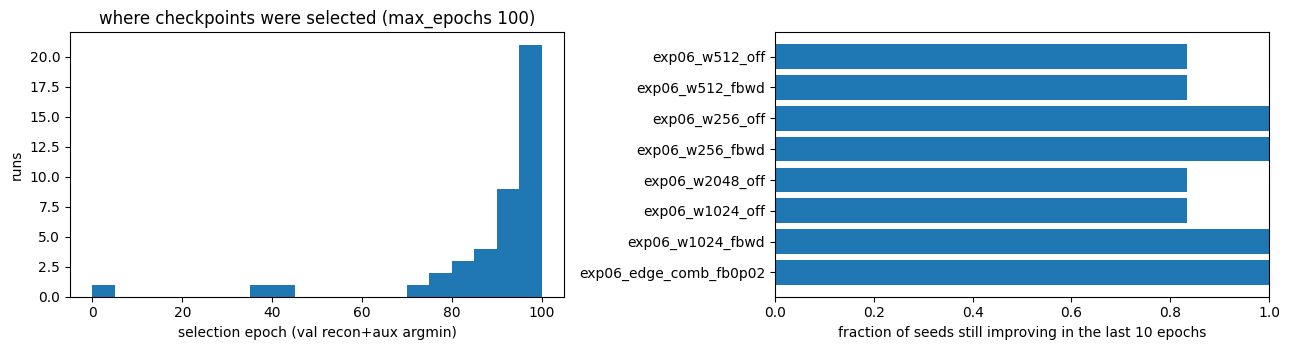

,best_epoch_med,improving
cell,,
exp06_edge_comb_fb0p02,38.0,1
exp06_w1024_fbwd,89.0,6
exp06_w1024_off,91.0,5
exp06_w2048_off,95.0,5
exp06_w256_fbwd,96.0,6
exp06_w256_off,91.5,6
exp06_w512_fbwd,96.0,5
exp06_w512_off,97.5,5


In [5]:
# A2 - convergence: selection epoch under the lambda-independent gate, and the still-improving flag
sel = []
for cell, w, seed in ALL_RUNS:
    cur = load_curve(cell, seed)
    best_i = cur["val/monitor_recon_aux"].idxmin()
    best_ep = int(cur.loc[best_i, "epoch"])
    last_ep = int(cur["epoch"].max())
    sel.append({"cell": cell, "window": w, "seed": seed, "best_epoch": best_ep,
                "last_epoch": last_ep, "improving_at_freeze": best_ep >= last_ep - 10})
sel = pd.DataFrame(sel)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].hist(sel["best_epoch"], bins=np.arange(0, 105, 5))
axes[0].set_xlabel("selection epoch (val recon+aux argmin)"); axes[0].set_ylabel("runs")
axes[0].set_title("where checkpoints were selected (max_epochs 100)")
frac = sel.groupby("cell")["improving_at_freeze"].mean()
axes[1].barh(frac.index, frac.values)
axes[1].set_xlabel("fraction of seeds still improving in the last 10 epochs"); axes[1].set_xlim(0, 1)
plt.tight_layout(); fig.savefig(figs_dir / "A2_selection.png", dpi=120, bbox_inches="tight"); plt.show()
sel.groupby("cell").agg(best_epoch_med=("best_epoch", "median"), improving=("improving_at_freeze", "sum"))

#### Plain-English read of A2

exp05 froze at epoch 60 with 44/48 runs still improving; ep100 was supposed to close that, and it did not: median selection epoch is 89-97 per cell and 5-6 of 6 seeds in every cell still select within their last 10 epochs. The truncation phenomenon (exp03 H5) persists at 100 epochs; the paired comparisons below stay valid because both arms share it, but absolute levels are still ceilings-in-progress, and any exp07 cell that matters should budget more epochs or a convergence-based stop.

In [6]:
# A3 - NaN / divergence check across the core logged metrics
core = ["val/recon", "val/aux", "val/n_active_units", "train/recon", "train/dyn", "val/mu_var"]
nan_counts = {}
for col in core:
    nan_counts[col] = 0
for cell, w, seed in ALL_RUNS:
    cur = load_curve(cell, seed)
    for col in core:
        nan_counts[col] += int(cur[col].isna().sum())
nan_table = pd.Series(nan_counts, name="nan_rows")
assert nan_table.sum() == 0, f"NaN in logged metrics: {nan_table[nan_table > 0]}"
nan_table.to_frame()

,nan_rows
val/recon,0
val/aux,0
val/n_active_units,0
train/recon,0
train/dyn,0
val/mu_var,0


In [7]:
# A4 - did lambda buy the dynamics contribution the pilots calibrated for (target 1.0 x recon)?
rows = []
for w, cell in FBWD_CELLS.items():
    for seed in SEEDS:
        cur = load_curve(cell, seed)
        tail = cur.tail(5)  # steady-state epochs, matching how the pilots read lambda
        contrib = LAMBDA[w] * tail["train/dyn"].mean() / tail["train/recon"].mean()
        rows.append({"window": w, "lambda": LAMBDA[w], "seed": seed, "achieved_contribution": contrib})
contrib = pd.DataFrame(rows)
contrib.groupby(["window", "lambda"])["achieved_contribution"].agg(["mean", "std"]).round(3)

,,mean,std
window,lambda,,
256,66,0.982,0.096
512,18,0.275,0.005
1024,18,0.342,0.004


#### Plain-English read of A4

The pilots set lambda so lambda x dyn lands at ~1.0x recon at steady state (66 at w256 from exp05; 18 at w512/w1024 from the 8-epoch pilots). w256 delivered: 0.98 +/- 0.10. The larger windows did NOT: the achieved contribution is ~0.28 at w512 and ~0.34 at w1024, because dyn kept shrinking relative to recon long past the epoch-7 pilot readout. The manifest pre-registered this direction ("achieved contribution may run under 1.0, recorded at eval") but the magnitude is a 3x shortfall, not a slight one; so in section E the weakening of the C1 benefit with window conflates geometry with dose, and "fwd+bwd at target contribution never got tested at w512/w1024" is the honest statement.

In [8]:
# A5 - cosine LR schedule sanity: starts at 3e-4 and decays along the cosine
# Runs stopped early by patience end mid-decay (e.g. w2048_off seed 0 stops at epoch 83, lr 2.4e-5),
# so the check is "the cosine ran and decayed", not "lr reached lr_min".
rows = []
for w, cell in sorted({**OFF_CELLS, **FBWD_CELLS}.items(), key=lambda kv: kv[0]):
    cur = load_curve(cell, 0)
    rows.append({"cell": cell, "n_epochs": int(cur["epoch"].max()) + 1,
                 "lr_first": cur["lr"].iloc[0], "lr_last": cur["lr"].iloc[-1],
                 "monotone_decay": bool((cur["lr"].diff().dropna() <= 1e-12).all())})
lr = pd.DataFrame(rows)
assert (lr["lr_first"] > 2e-4).all() and (lr["lr_last"] < lr["lr_first"] / 5).all() and lr["monotone_decay"].all()
lr

,cell,n_epochs,lr_first,lr_last,monotone_decay
0,exp06_w256_fbwd,94,0.0003,0.000007,True
1,exp06_w512_fbwd,100,0.0003,0.000003,True
2,exp06_w1024_fbwd,100,0.0003,0.000003,True
3,exp06_w2048_off,84,0.0003,0.000024,True


## B. Capacity and latent health

The window sweep is not capacity-neutral: the decoder grows with the window, which is why every gap in exp06 is measured against a per-geometry capacity-matched untrained reference, never a shared one.

In [9]:
# B1 - parameter count per geometry (model block identical across cells; only window varies)
rows = []
for w in [256, 512, 1024, 2048]:
    m = WorldModel(in_ch=1, enc_channels=[32, 64, 128, 256], kernel_size=5, z_dim=128,
                   window=w, gru_hidden=256, gru_layers=1)
    n_params = 0
    for p in m.parameters():
        n_params += p.numel()
    rows.append({"window": w, "hours": w * 2 / 60, "params_M": n_params / 1e6})
pd.DataFrame(rows).round(2)

,window,hours,params_M
0,256,8.53,2.30
1,512,17.07,3.87
2,1024,34.13,7.03
3,2048,68.27,13.33


#### Plain-English read of B1

Params grow ~6x from 256 to 2048, so "bigger window scores better" could have been a pure capacity artifact; the per-geometry untrained reference (same constructor, fixed seed-0 init) removes exactly that confound, and section G shows the trained-untrained gap on that footing.

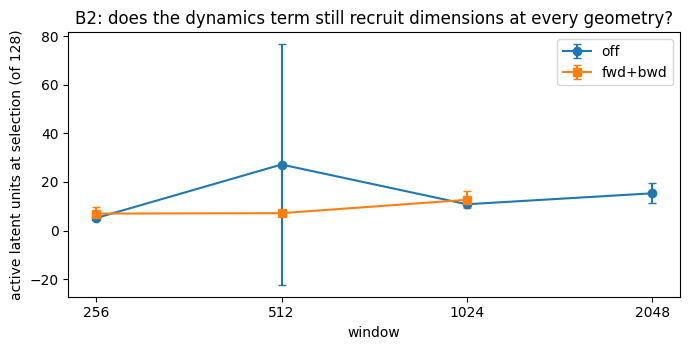

,window,arm,mean,std
0,256,fwd+bwd,7.0,2.8
1,256,off,5.2,0.4
2,512,fwd+bwd,7.2,0.8
3,512,off,27.2,49.4
4,1024,fwd+bwd,12.7,3.6
5,1024,off,10.8,0.8
6,2048,off,15.3,4.1


In [10]:
# B2 - collapse-reversal at each geometry: active units at the selection epoch, off vs fwd+bwd
rows = []
for arm, cells in [("off", OFF_CELLS), ("fwd+bwd", FBWD_CELLS)]:
    for w, cell in cells.items():
        for seed in SEEDS:
            cur = load_curve(cell, seed)
            best_i = cur["val/monitor_recon_aux"].idxmin()
            rows.append({"arm": arm, "window": w, "seed": seed,
                         "n_active": cur.loc[best_i, "val/n_active_units"]})
act = pd.DataFrame(rows)
agg = act.groupby(["window", "arm"])["n_active"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(7, 3.6))
for arm, marker in [("off", "o"), ("fwd+bwd", "s")]:
    a = agg[agg["arm"] == arm]
    plt.errorbar(a["window"], a["mean"], yerr=a["std"], marker=marker, capsize=3, label=arm)
plt.xscale("log", base=2); plt.xticks([256, 512, 1024, 2048], ["256", "512", "1024", "2048"])
plt.xlabel("window"); plt.ylabel("active latent units at selection (of 128)")
plt.legend(); plt.title("B2: does the dynamics term still recruit dimensions at every geometry?")
plt.tight_layout(); plt.savefig(figs_dir / "B2_n_active.png", dpi=120, bbox_inches="tight"); plt.show()
agg.round(1)

#### Plain-English read of B2

Measured at the SELECTED checkpoints, the exp05 collapse-reversal picture is mostly gone: fwd+bwd sits at 7.0 +/- 2.8 active units at w256 vs 5.2 +/- 0.4 off, and the arms overlap at every other geometry (the w512 off bar's huge spread is one runaway seed that kept ~100 units alive). This is not a contradiction of exp05, which read n_active at the epoch-60 freeze; B3 shows why the two snapshots disagree.

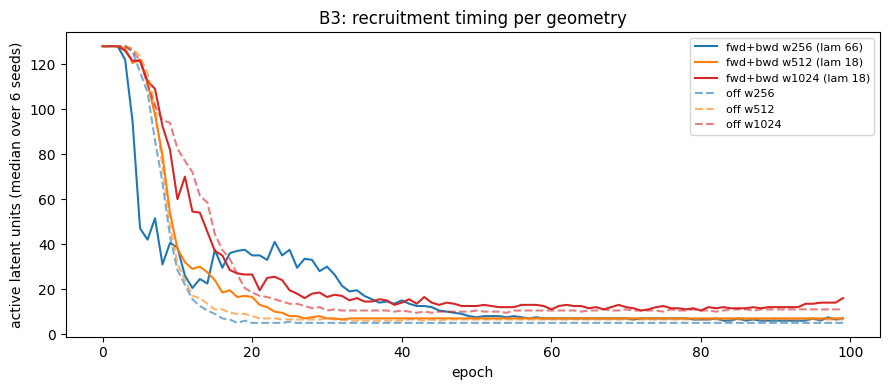

In [11]:
# B3 - recruitment timing: when during the 100 epochs do the dimensions arrive? (new analysis cell)
plt.figure(figsize=(9, 4))
colors = {256: "tab:blue", 512: "tab:orange", 1024: "tab:red"}
for w, cell in FBWD_CELLS.items():
    per_seed = []
    for seed in SEEDS:
        cur = load_curve(cell, seed)
        per_seed.append(cur.set_index("epoch")["val/n_active_units"])
    med = pd.concat(per_seed, axis=1).median(axis=1)
    plt.plot(med.index, med.values, color=colors[w], label=f"fwd+bwd w{w} (lam {LAMBDA[w]})")
for w, cell in OFF_CELLS.items():
    if w == 2048:
        continue
    per_seed = []
    for seed in SEEDS:
        cur = load_curve(cell, seed)
        per_seed.append(cur.set_index("epoch")["val/n_active_units"])
    med = pd.concat(per_seed, axis=1).median(axis=1)
    plt.plot(med.index, med.values, color=colors[w], ls="--", alpha=0.6, label=f"off w{w}")
plt.xlabel("epoch"); plt.ylabel("active latent units (median over 6 seeds)")
plt.legend(fontsize=8); plt.title("B3: recruitment timing per geometry")
plt.tight_layout(); plt.savefig(figs_dir / "B3_recruitment.png", dpi=120, bbox_inches="tight"); plt.show()

#### Plain-English read of B3

**Recruitment is a transient, and this is the notebook's one genuinely new mechanism observation.** At w256 the fwd+bwd arm re-recruits to ~40 active units around epochs 15-35 (the exp05 freeze at 60 caught the tail of this bump, hence "25 +/- 15"), then decays back under 10 by epoch 50 as the cosine LR anneals; the selected checkpoints (median epoch 89+) sit long after the bump. Yet section E shows criterion 1 replicating at exactly these low-n_active checkpoints, so the representational benefit of the dynamics term does not require an elevated active-unit count at selection: it is deposited during the transient and survives the re-collapse. This strengthens exp05's E4b verdict that n_active is not the mechanism carrier and must not be used for selection.

## C. H1 verdict : is window length the binding constraint for period-dominated tasks?

Pre-registered gates (manifest, grill 2026-07-27), all on the dyn-on arm with amplitude-residualized mean-pooled mu: H1-a Delta_g(eb) - Delta_g(pulsating) > 2*SE and H1-b Delta_g(rotation) - Delta_g(pulsating) > 2*SE for g in {512, 1024} vs 256, with pulsating (93% single-window coverage) as the must-not-improve control.

In [12]:
# C1 - recompute the four gates from the gap CSV and assert they match exp06_gates.csv
def pivot(cells, pooling, task):
    """Seed-by-window PR-AUC matrix for one arm/pooling/task, mirroring analyze_exp06_gates.py."""
    rows = gap[(gap["pooling"] == pooling) & (gap["task"] == task) & (gap["seed"] >= 0)
               & (gap["cell"].isin(cells.values()))]
    return rows.pivot(index="seed", columns="window", values="pr_auc")


def paired(deltas):
    """Mean, SE over seeds, and the one-sided > 2*SE gate."""
    mean = float(deltas.mean())
    se = float(deltas.std(ddof=1) / np.sqrt(len(deltas)))
    return mean, se, bool(mean > 2 * se)


recomputed = []
mats = {}
for task in TASKS:
    mats[task] = pivot(FBWD_CELLS, "mean_resid", task)
for g in (512, 1024):
    d = {}
    for task in TASKS:
        d[task] = (mats[task][g] - mats[task][256]).to_numpy()
    for gate_name, diff in [("H1-a eb-puls", d["eb"] - d["pulsating"]),
                            ("H1-b rot-puls", d["rotation"] - d["pulsating"])]:
        mean, se, passed = paired(diff)
        recomputed.append({"gate": gate_name, "geometry": g, "mean": mean, "se": se, "pass": passed})
recomputed = pd.DataFrame(recomputed).sort_values(["gate", "geometry"]).reset_index(drop=True)

stored = gates[(gates["is_gate"]) & (gates["gate"].str.startswith("H1"))]
stored = stored.sort_values(["gate", "geometry"]).reset_index(drop=True)
assert np.allclose(recomputed["mean"], stored["mean"], atol=1e-9)
assert np.allclose(recomputed["se"], stored["se"], atol=1e-9)
assert (recomputed["pass"] == stored["pass"]).all()
print("independent gate recomputation matches exp06_gates.csv")
recomputed.round(4)

independent gate recomputation matches exp06_gates.csv


,gate,geometry,mean,se,pass
0,H1-a eb-puls,512,-0.0074,0.0201,False
1,H1-a eb-puls,1024,0.0101,0.0233,False
2,H1-b rot-puls,512,-0.0413,0.0187,False
3,H1-b rot-puls,1024,0.0141,0.0203,False


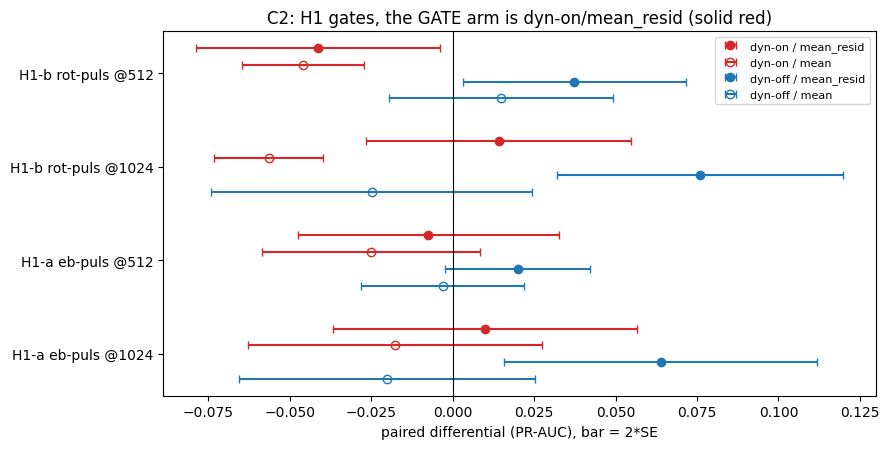

In [13]:
# C2 - the gate forest: all H1 differentials, gate arm solid, dyn-off robustness hollow
h1 = gates[gates["gate"].str.startswith("H1")].copy()
h1["row"] = h1["gate"] + " @" + h1["geometry"].astype(int).astype(str)
order = sorted(h1["row"].unique())
offsets = {("dyn-on", "mean_resid"): 0.27, ("dyn-on", "mean"): 0.09,
           ("dyn-off", "mean_resid"): -0.09, ("dyn-off", "mean"): -0.27}
colors = {"dyn-on": "tab:red", "dyn-off": "tab:blue"}

plt.figure(figsize=(9, 4.6))
for (arm, pooling), off in offsets.items():
    sub = h1[(h1["arm"] == arm) & (h1["pooling"] == pooling)]
    y = [order.index(r) + off for r in sub["row"]]
    filled = "full" if pooling == "mean_resid" else "none"
    plt.errorbar(sub["mean"], y, xerr=2 * sub["se"], fmt="o", fillstyle=filled,
                 color=colors[arm], capsize=3, label=f"{arm} / {pooling}")
plt.axvline(0, color="k", lw=0.8)
plt.yticks(range(len(order)), order); plt.xlabel("paired differential (PR-AUC), bar = 2*SE")
plt.legend(fontsize=8); plt.title("C2: H1 gates, the GATE arm is dyn-on/mean_resid (solid red)")
plt.tight_layout(); plt.savefig(figs_dir / "C2_gate_forest.png", dpi=120, bbox_inches="tight"); plt.show()

#### Plain-English read of C2

**H1 is not supported.** All four gate-arm differentials fail (eb-puls @512 -0.007 +/- 0.020, @1024 +0.010 +/- 0.023; rot-puls @512 -0.041 +/- 0.019, @1024 +0.014 +/- 0.020). The dyn-off arm shows three nominal passes, but C3 shows they are an artifact of the control moving, not of coverage helping.

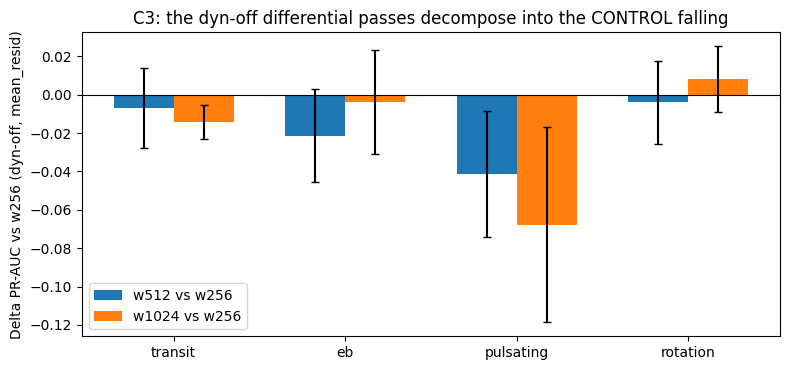

,task,geometry,delta_vs_256,se,abs_256,abs_g
0,transit,512,-0.0068,0.0104,0.1267,0.1198
1,transit,1024,-0.0142,0.0044,0.1267,0.1125
2,eb,512,-0.0214,0.0121,0.5224,0.5010
3,eb,1024,-0.0038,0.0135,0.5224,0.5186
4,pulsating,512,-0.0414,0.0165,0.7575,0.7162
5,pulsating,1024,-0.0677,0.0255,0.7575,0.6898
6,rotation,512,-0.0041,0.0107,0.3812,0.3771
7,rotation,1024,0.0082,0.0086,0.3812,0.3894


In [14]:
# C3 - decomposition of the dyn-off "passes": which task actually moved between geometries?
# mean_resid pooling: the arm where the dyn-off differentials nominally passed (C2 blue solid).
rows = []
mats_off = {}
for task in TASKS:
    mats_off[task] = pivot({k: v for k, v in OFF_CELLS.items() if k != 2048}, "mean_resid", task)
for task in TASKS:
    for g in (512, 1024):
        d = (mats_off[task][g] - mats_off[task][256]).to_numpy()
        mean, se, _ = paired(d)
        rows.append({"task": task, "geometry": g, "delta_vs_256": mean, "se": se,
                     "abs_256": mats_off[task][256].mean(), "abs_g": mats_off[task][g].mean()})
dec = pd.DataFrame(rows)

plt.figure(figsize=(8, 3.8))
x = np.arange(len(TASKS))
for i, g in enumerate([512, 1024]):
    sub = dec[dec["geometry"] == g].set_index("task").loc[TASKS]
    plt.bar(x + (i - 0.5) * 0.35, sub["delta_vs_256"], 0.35,
            yerr=2 * sub["se"], capsize=3, label=f"w{g} vs w256")
plt.axhline(0, color="k", lw=0.8)
plt.xticks(x, TASKS); plt.ylabel("Delta PR-AUC vs w256 (dyn-off, mean_resid)")
plt.legend(); plt.title("C3: the dyn-off differential passes decompose into the CONTROL falling")
plt.tight_layout(); plt.savefig(figs_dir / "C3_decomposition.png", dpi=120, bbox_inches="tight"); plt.show()
dec.round(4)

#### Plain-English read of C3

The pulsating control falls from 0.758 to 0.690 as the window grows 256 to 1024 while eb (-0.004) and rotation (+0.008) stay flat: a differential "pass" produced entirely by the subtrahend dropping. That is control degradation, not a coverage gain, which is exactly the failure mode the pulsating control was pre-registered to catch.

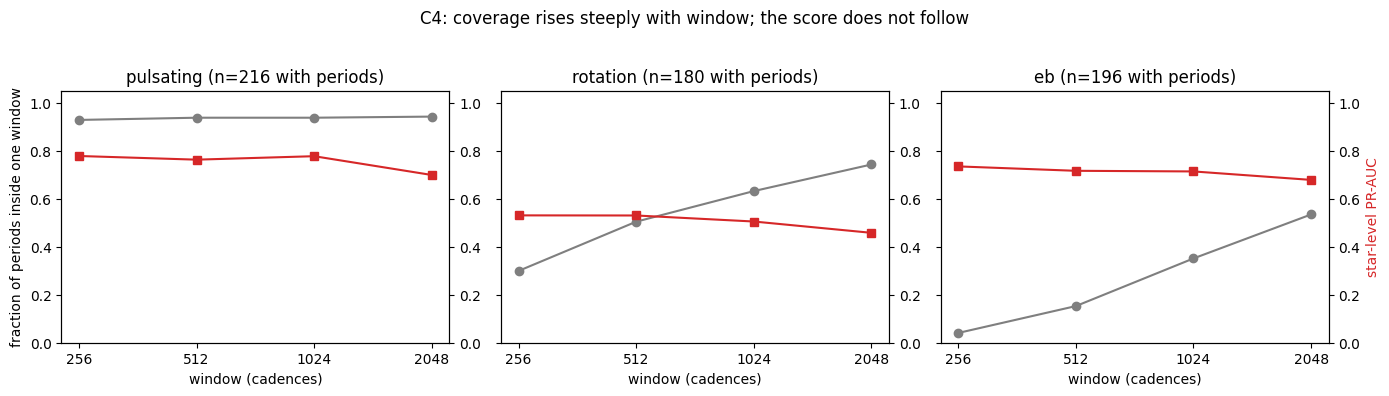

In [15]:
# C4 - coverage overlay (new analysis cell): catalogued period coverage vs the flat score curve
labels = pd.read_csv(root / "labels" / "variability_labels_star.csv",
                     usecols=["tic_id", "eb", "eb_period", "pulsating", "pulsating_period",
                              "rotation", "rotation_period"])
test_lab = subset[subset["split"] == "test"].merge(labels, on="tic_id", how="left", suffixes=("", "_cat"))
window_days = {}
for w in [256, 512, 1024, 2048]:
    window_days[w] = w * 2 / (60 * 24)  # 2-min cadence --> days

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for ax, task in zip(axes, ["pulsating", "rotation", "eb"]):
    periods = test_lab.loc[test_lab[task] == 1, f"{task}_period"].dropna()
    cov = []
    score = []
    for w in [256, 512, 1024, 2048]:
        cov.append(float((periods <= window_days[w]).mean()))
        s = gap[(gap["pooling"] == "mean") & (gap["task"] == task) & (gap["seed"] >= 0)
                & (gap["cell"].isin(OFF_CELLS.values())) & (gap["window"] == w)]
        score.append(s["pr_auc"].mean())
    ax.plot([256, 512, 1024, 2048], cov, "o-", color="tab:grey", label="period coverage")
    ax.set_xscale("log", base=2); ax.set_xticks([256, 512, 1024, 2048], ["256", "512", "1024", "2048"])
    ax.set_ylim(0, 1.05); ax.set_title(f"{task} (n={len(periods)} with periods)")
    ax2 = ax.twinx()
    ax2.plot([256, 512, 1024, 2048], score, "s-", color="tab:red", label="PR-AUC (dyn-off, mean)")
    ax2.set_ylim(0, 1.05)
    if task == "eb":
        ax2.set_ylabel("star-level PR-AUC", color="tab:red")
    ax.set_xlabel("window (cadences)")
axes[0].set_ylabel("fraction of periods inside one window")
fig.suptitle("C4: coverage rises steeply with window; the score does not follow", y=1.03)
plt.tight_layout(); fig.savefig(figs_dir / "C4_coverage_overlay.png", dpi=120, bbox_inches="tight"); plt.show()

#### Plain-English read of C4

This is the H1 money plot: eb coverage climbs from ~4% at w256 to >50% at w2048 (median Villanova period 57 h vs an 8.5 h window) yet the star-level score stays flat and then drops at 2048. transit is absent because the TOI join does not retain a period column in the label schema; the geometry argument for it was always indirect.

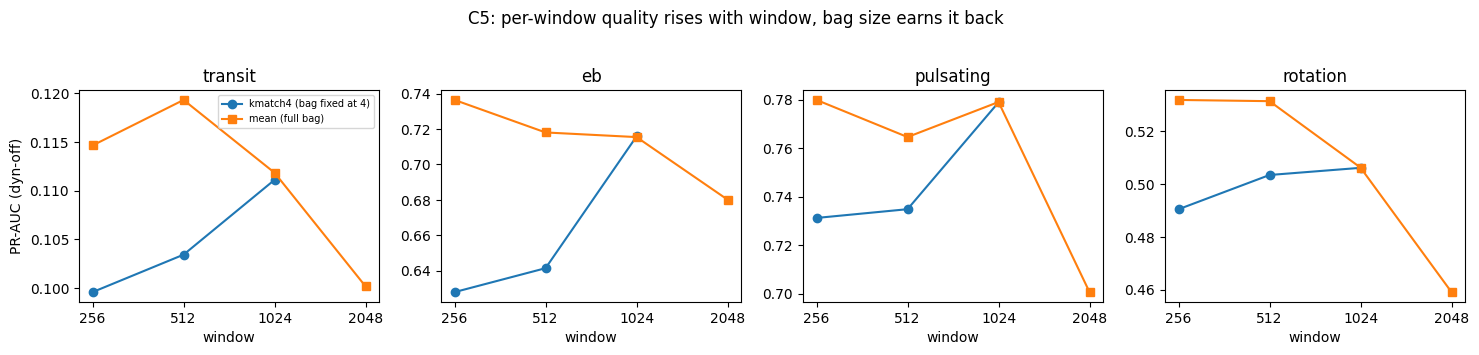

,task,window,kmatch4_gain_vs_256,mean_pool_gain_vs_256,expected_mean_if_no_bag_compensation,observed_mean
0,transit,512,0.004,0.005,0.118,0.119
1,transit,1024,0.012,-0.003,0.126,0.112
2,eb,512,0.014,-0.018,0.750,0.718
3,eb,1024,0.088,-0.021,0.824,0.715
4,pulsating,512,0.004,-0.015,0.784,0.765
5,pulsating,1024,0.048,-0.001,0.828,0.779
6,rotation,512,0.013,-0.000,0.545,0.531
7,rotation,1024,0.016,-0.026,0.548,0.506


In [16]:
# C5 - cancellation arithmetic (new analysis cell): per-window quality vs what the star level observed
rows = []
for task in TASKS:
    k = {}
    m = {}
    for w in [256, 512, 1024, 2048]:
        sub_m = gap[(gap["pooling"] == "mean") & (gap["task"] == task) & (gap["seed"] >= 0)
                    & (gap["cell"].isin(OFF_CELLS.values())) & (gap["window"] == w)]
        m[w] = sub_m["pr_auc"].mean()
        sub_k = gap[(gap["pooling"] == "kmatch4") & (gap["task"] == task) & (gap["seed"] >= 0)
                    & (gap["cell"].isin(OFF_CELLS.values())) & (gap["window"] == w)]
        if len(sub_k):
            k[w] = sub_k["pr_auc"].mean()
    for w in [512, 1024]:
        rows.append({"task": task, "window": w,
                     "kmatch4_gain_vs_256": k[w] - k[256],
                     "mean_pool_gain_vs_256": m[w] - m[256],
                     "expected_mean_if_no_bag_compensation": m[256] + (k[w] - k[256]),
                     "observed_mean": m[w]})
canc = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), sharex=True)
for ax, task in zip(axes, TASKS):
    sub = gap[(gap["task"] == task) & (gap["seed"] >= 0) & (gap["cell"].isin(OFF_CELLS.values()))]
    for pooling, marker, label in [("kmatch4", "o", "kmatch4 (bag fixed at 4)"), ("mean", "s", "mean (full bag)")]:
        by_w = sub[sub["pooling"] == pooling].groupby("window")["pr_auc"].mean()
        ax.plot(by_w.index, by_w.values, marker + "-", label=label)
    ax.set_xscale("log", base=2); ax.set_xticks([256, 512, 1024, 2048], ["256", "512", "1024", "2048"])
    ax.set_title(task); ax.set_xlabel("window")
axes[0].set_ylabel("PR-AUC (dyn-off)"); axes[0].legend(fontsize=7)
fig.suptitle("C5: per-window quality rises with window, bag size earns it back", y=1.03)
plt.tight_layout(); fig.savefig(figs_dir / "C5_cancellation.png", dpi=120, bbox_inches="tight"); plt.show()
canc.round(3)

#### Plain-English read of C5

With the bag fixed at 4 windows, per-window representation quality genuinely improves with window (eb 0.628 --> 0.716, pulsating 0.731 --> 0.779), so longer windows do see more per window. But at a fixed cadence budget the smaller geometries hold 16 vs 8 vs 4 windows per star, and the table's "expected if no bag compensation" column shows the star level would have gained the full per-window improvement; the observed mean-pool column shows it gained ~none. Window length is a granularity-neutral knob, not the binding constraint. kmatch4 was not computed at w2048 (trajectories there are 2 windows long).

## D. H2 verdict : is the rollout axis worth re-opening at longer windows?

Pre-gate: rollout evaluation re-opens only where the lag-1 mu-trajectory ACF on periodic stars reaches 0.3; exp06_design_forensics measured ~0.017 at w256 and predicted the axis is ill-posed at that geometry.

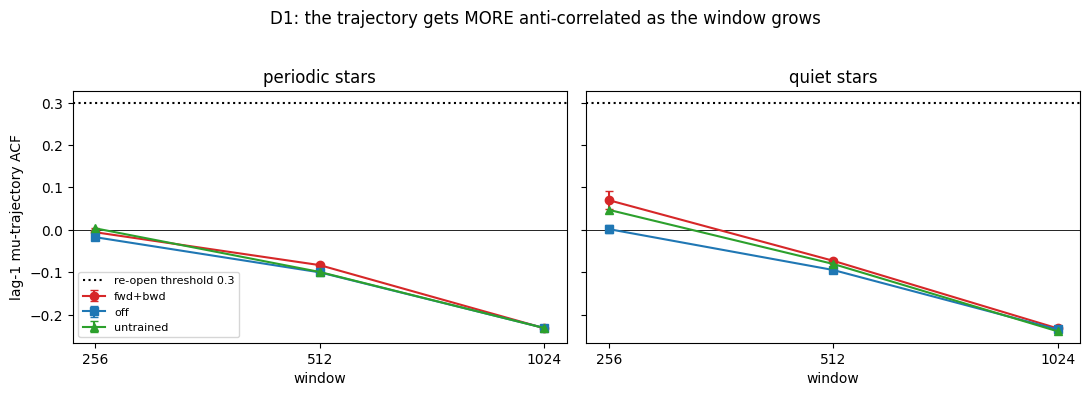

In [17]:
# D1 - lag-1 mu-ACF vs window: trained arms and untrained reference, periodic and quiet stars
a1 = acf[acf["lag"] == 1]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
groups = [("fwd+bwd", FBWD_CELLS.values(), "tab:red", "o"),
          ("off", [c for w, c in OFF_CELLS.items() if w != 2048], "tab:blue", "s"),
          ("untrained", ["untrained_w256", "untrained_w512", "untrained_w1024"], "tab:green", "^")]
for ax, cls in zip(axes, ["periodic", "quiet"]):
    for label, cells, color, marker in groups:
        sub = a1[(a1["cls"] == cls) & (a1["cell"].isin(list(cells)))]
        by_w = sub.groupby("window")["acf"].agg(["mean", "sem"])
        ax.errorbar(by_w.index, by_w["mean"], yerr=2 * by_w["sem"], marker=marker,
                    color=color, capsize=3, label=label)
    ax.axhline(0.3, color="k", ls=":", label="re-open threshold 0.3")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xscale("log", base=2); ax.set_xticks([256, 512, 1024], ["256", "512", "1024"])
    ax.set_title(f"{cls} stars"); ax.set_xlabel("window")
axes[0].set_ylabel("lag-1 mu-trajectory ACF"); axes[0].legend(fontsize=8)
fig.suptitle("D1: the trajectory gets MORE anti-correlated as the window grows", y=1.03)
plt.tight_layout(); fig.savefig(figs_dir / "D1_acf_lag1.png", dpi=120, bbox_inches="tight"); plt.show()

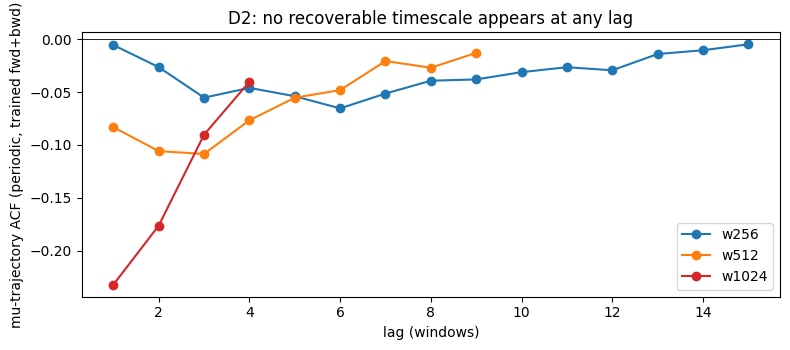

In [18]:
# D2 - the full lag profile on periodic stars, fwd+bwd arm, one line per geometry
plt.figure(figsize=(8, 3.6))
colors = {256: "tab:blue", 512: "tab:orange", 1024: "tab:red"}
for w, cell in FBWD_CELLS.items():
    sub = acf[(acf["cell"] == cell) & (acf["cls"] == "periodic")]
    by_lag = sub.groupby("lag")["acf"].mean()
    plt.plot(by_lag.index, by_lag.values, "o-", color=colors[w], label=f"w{w}")
plt.axhline(0, color="k", lw=0.6)
plt.xlabel("lag (windows)"); plt.ylabel("mu-trajectory ACF (periodic, trained fwd+bwd)")
plt.legend(); plt.title("D2: no recoverable timescale appears at any lag")
plt.tight_layout(); plt.savefig(figs_dir / "D2_acf_profile.png", dpi=120, bbox_inches="tight"); plt.show()

#### Plain-English read of D

**Rollout evaluation stays closed at every geometry.** Lag-1 ACF on periodic stars goes -0.006 (256) to -0.083/-0.100 (512) to -0.232 (1024): longer windows make consecutive embeddings MORE anti-correlated, never approaching the 0.3 threshold. The untrained reference tracks the trained arms almost exactly, so the anti-correlation is a property of how windowing samples the flux, not something training created. w2048 is absent by construction (its per-star trajectories are 2 windows long, and lag-1 ACF of a 2-point series is deterministically -0.5, so the eval guard requires T >= 3). Criterion-2-style rollout physics is closed for the whole v1 window family; the exp07 lever for this is the objective (phase-aware aux), not geometry.

## E. C1 replication : does the exp05 dynamics-weighting win survive ep100, 6 seeds, and new geometries?

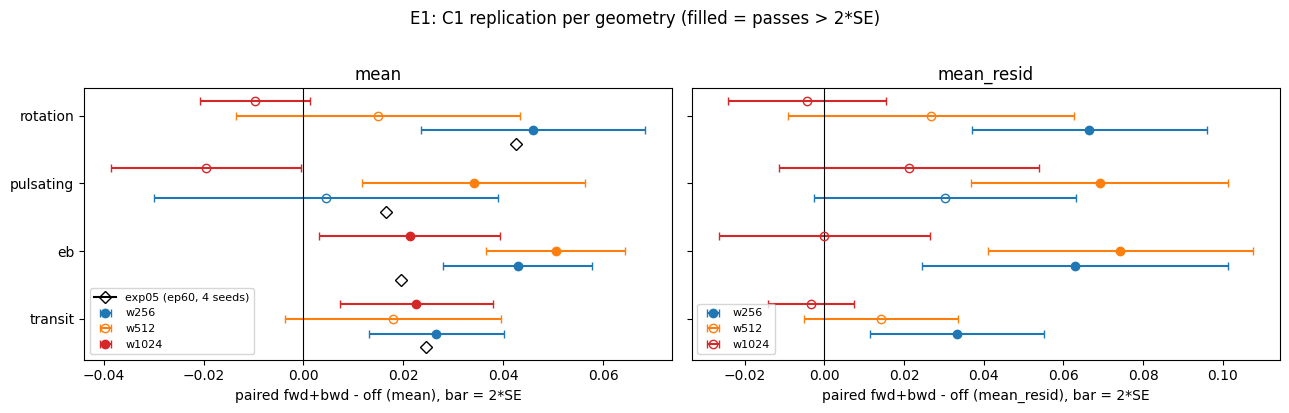

In [19]:
# E1 - paired fwd+bwd minus off per geometry, with exp05's 4-seed result overlaid at w256
exp05_gap = pd.read_csv(root / "experiments" / "exp05_gap.csv")
e5 = exp05_gap[exp05_gap["cell"] == "fbwd_c1p0"].set_index("task")

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
colors = {256: "tab:blue", 512: "tab:orange", 1024: "tab:red"}
for ax, pooling in zip(axes, ["mean", "mean_resid"]):
    for gi, g in enumerate([256, 512, 1024]):
        for ti, task in enumerate(TASKS):
            on = pivot(FBWD_CELLS, pooling, task)[g].to_numpy()
            base = pivot({k: v for k, v in OFF_CELLS.items() if k != 2048}, pooling, task)[g].to_numpy()
            mean, se, passed = paired(on - base)
            y = ti + (gi - 1) * 0.22
            face = "full" if passed else "none"
            ax.errorbar(mean, y, xerr=2 * se, fmt="o", fillstyle=face, color=colors[g], capsize=3,
                        label=f"w{g}" if ti == 0 else None)
    if pooling == "mean":
        for ti, task in enumerate(TASKS):
            ax.plot(e5.loc[task, "delta_vs_off_mean"], ti - 0.42, marker="D", color="k",
                    fillstyle="none", ms=6, label="exp05 (ep60, 4 seeds)" if ti == 0 else None)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_yticks(range(len(TASKS)), TASKS); ax.set_xlabel(f"paired fwd+bwd - off ({pooling}), bar = 2*SE")
    ax.set_title(pooling); ax.legend(fontsize=8)
fig.suptitle("E1: C1 replication per geometry (filled = passes > 2*SE)", y=1.02)
plt.tight_layout(); fig.savefig(figs_dir / "E1_c1_replication.png", dpi=120, bbox_inches="tight"); plt.show()

#### Plain-English read of E1

**C1 replicates at 256x16 under the stricter protocol** (ep100, 6 seeds: eb +0.043 +/- 0.007, rotation +0.046 +/- 0.011, transit +0.027 +/- 0.007 all pass; pulsating ns), so the exp05 headline was not a truncation or seed-count artifact; the black diamonds show exp05's own 4-seed values landing inside the new bars. The benefit weakens with window (at 1024 only eb/transit pass on raw mean, nothing on residualized) and one new pass appears (pulsating +0.034 at 512), but A4 qualifies the geometry reading: the achieved dyn contribution ran at only ~0.3x target at w512/w1024, so dose and geometry are conflated there, and w256 is the only geometry where full-dose fwd+bwd was actually tested.

## F. Edge confirmation : which knob confers immunity to the window-edge spike?

exp06_design_forensics predicted the spike would SURVIVE `comb + free_bits=0.02 + fwd_bwd@66` because the immunity mechanism belongs to `recon_aux` (an injected impulse raises log-PSD 10-31x more than time-MSE), not to `free_bits`. The 1-seed confirmation cell tests exactly that.

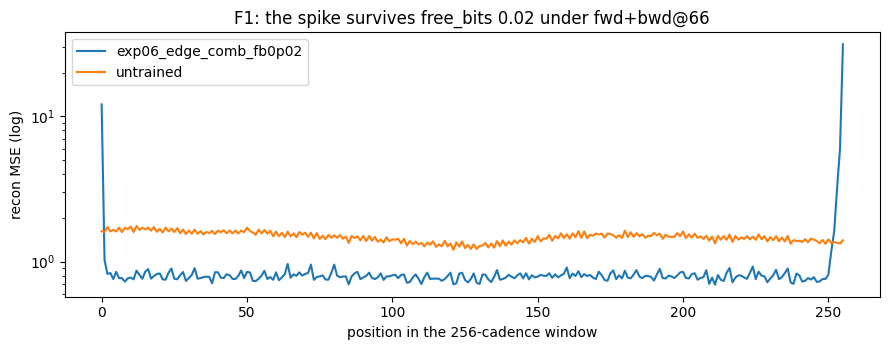

,cell,edge_ratio,bias_frac_p0,jac_ratio,dmu_ratio,aux_over_time_response
0,exp06_edge_comb_fb0p02,15.279,0.718,2.372,2.382,-20.081
1,untrained,1.094,0.060,0.273,0.507,-31.388


In [20]:
# F1 - per-position reconstruction error profile and the corner-cell metrics
corner = pd.read_csv(root / "experiments" / "exp06_edge_corner.csv")
profile = pd.read_parquet(root / "experiments" / "exp06_edge_corner.parquet")

plt.figure(figsize=(9, 3.6))
for cell_name, grp in profile.groupby("cell"):
    by_pos = grp.groupby("pos")["mse"].mean()
    plt.semilogy(by_pos.index, by_pos.values, label=cell_name)
plt.xlabel("position in the 256-cadence window"); plt.ylabel("recon MSE (log)")
plt.legend(); plt.title("F1: the spike survives free_bits 0.02 under fwd+bwd@66")
plt.tight_layout(); plt.savefig(figs_dir / "F1_edge_profile.png", dpi=120, bbox_inches="tight"); plt.show()
corner[["cell", "edge_ratio", "bias_frac_p0", "jac_ratio", "dmu_ratio", "aux_over_time_response"]].round(3)

#### Plain-English read of F1

**Prediction confirmed.** The confirmation cell spikes at edge ratio 15.3x (the exp05 fwd+bwd group mean was 17.5x), with bias fraction 0.72 and a trained Jacobian inversion of 2.37 vs 0.27 untrained: adding free_bits 0.02 changed nothing, so free_bits is exonerated and `recon_aux` is the immunity knob. This closes the open question in `.scratch/exp05-window-edge-defect`; the fix (log-PSD-only aux or an edge-side decoder change, with ADR) is exp07 work.

## G. Trained - untrained gaps : is SSL learning real at every geometry?

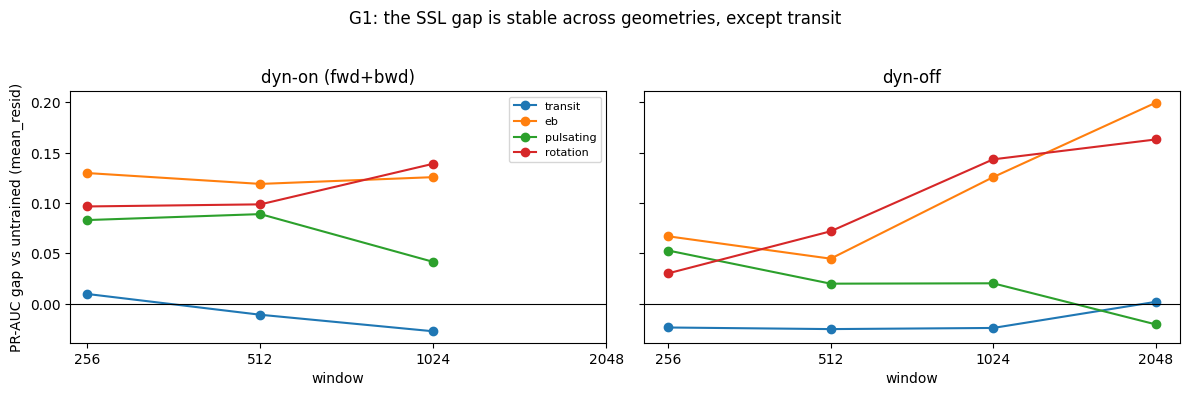

In [21]:
# G1 - trained minus capacity-matched untrained, per task and geometry, both arms
unt = gap[gap["arm"] == "untrained"]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, (arm_label, cells) in zip(axes, [("dyn-on (fwd+bwd)", FBWD_CELLS), ("dyn-off", OFF_CELLS)]):
    for task in TASKS:
        xs = []
        ys = []
        for g, cell in cells.items():
            tr = gap[(gap["cell"] == cell) & (gap["pooling"] == "mean_resid")
                     & (gap["task"] == task) & (gap["seed"] >= 0)]["pr_auc"].mean()
            un = unt[(unt["window"] == g) & (unt["pooling"] == "mean_resid")
                     & (unt["task"] == task)]["pr_auc"].mean()
            xs.append(g); ys.append(tr - un)
        ax.plot(xs, ys, "o-", label=task)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xscale("log", base=2); ax.set_xticks([256, 512, 1024, 2048], ["256", "512", "1024", "2048"])
    ax.set_title(arm_label); ax.set_xlabel("window")
axes[0].set_ylabel("PR-AUC gap vs untrained (mean_resid)"); axes[0].legend(fontsize=8)
fig.suptitle("G1: the SSL gap is stable across geometries, except transit", y=1.03)
plt.tight_layout(); fig.savefig(figs_dir / "G1_gaps.png", dpi=120, bbox_inches="tight"); plt.show()

#### Plain-English read of G1

SSL learning is real at every window: eb holds +0.12 to +0.13 and rotation +0.10 to +0.14 against the per-geometry capacity-matched untrained reference, so the H1 failure is not "training stopped working at bigger windows". The one exception is transit, whose gap goes negative at 512/1024: the weakest, most localized signal is the first casualty of coarser granularity, matching the MIL dispersion story.

## H. Lightcurves : the same star at four windows

What the geometry sweep looks like in flux space: one star per task class, its first common test segment reconstructed by each geometry's panel model over the same 2048 cadences (~2.8 d). Window boundaries are the grey verticals; the coverage story (an EB eclipse cut at 256 vs contained at 2048) is directly visible.

In [22]:
# H0 - models, packed memmaps, and the star pools common to all four geometries
PANEL = {256: ("exp06_w256_fbwd", f"fwd+bwd lam{LAMBDA[256]}"),
         512: ("exp06_w512_fbwd", f"fwd+bwd lam{LAMBDA[512]}"),
         1024: ("exp06_w1024_fbwd", f"fwd+bwd lam{LAMBDA[1024]}"),
         2048: ("exp06_w2048_off", "off (only arm at 2048)")}
models = {}
packs = {}
for w, (cell, label) in PANEL.items():
    models[w], _ = load_model(cell)
    packs[w] = load_packed(cell, w)

seg_keys = None
for w in PANEL:
    idx = packs[w][0]
    ok = idx[idx["n_win"] * w >= 2048].set_index(["tic_id", "sector", "seg_idx"])
    keys = set(ok.index)
    if seg_keys is None:
        seg_keys = keys
    else:
        seg_keys = seg_keys & keys
common = pd.DataFrame(sorted(seg_keys), columns=["tic_id", "sector", "seg_idx"])
common = common.sort_values(["tic_id", "sector", "seg_idx"]).drop_duplicates("tic_id")

test_lab = subset[subset["split"] == "test"].set_index("tic_id")
pools = {}
for task in TASKS + ["quiet"]:
    if task == "quiet":
        tics = test_lab[test_lab[TASKS].sum(axis=1) == 0].index
    else:
        tics = test_lab[test_lab[task] == 1].index
    pools[task] = [t for t in common["tic_id"] if t in set(tics)]
print("segments >= 2048 cadences in all four packs:", len(common),
      "| pool sizes:", {t: len(p) for t, p in pools.items()})

segments >= 2048 cadences in all four packs: 2021 | pool sizes: {'transit': 122, 'eb': 196, 'pulsating': 216, 'rotation': 180, 'quiet': 1500}


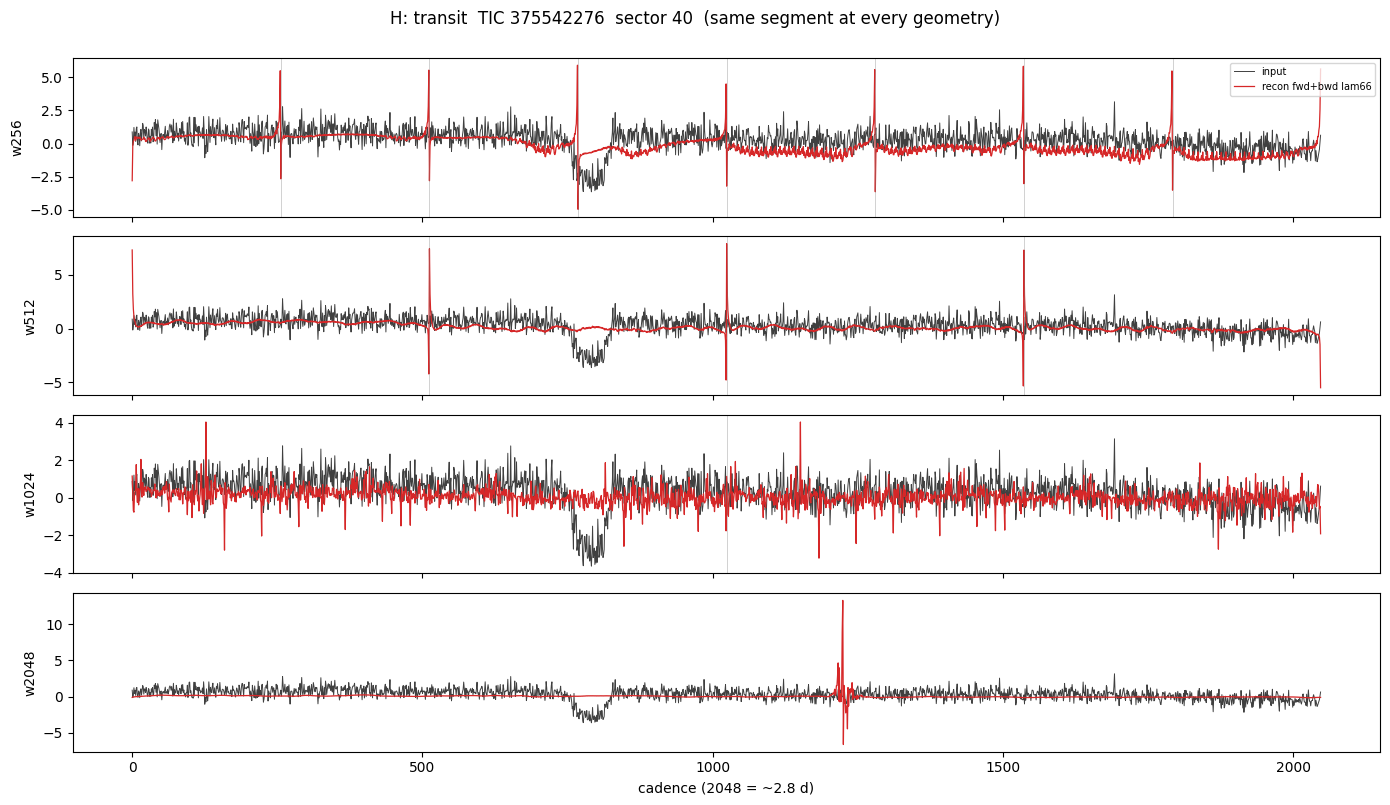

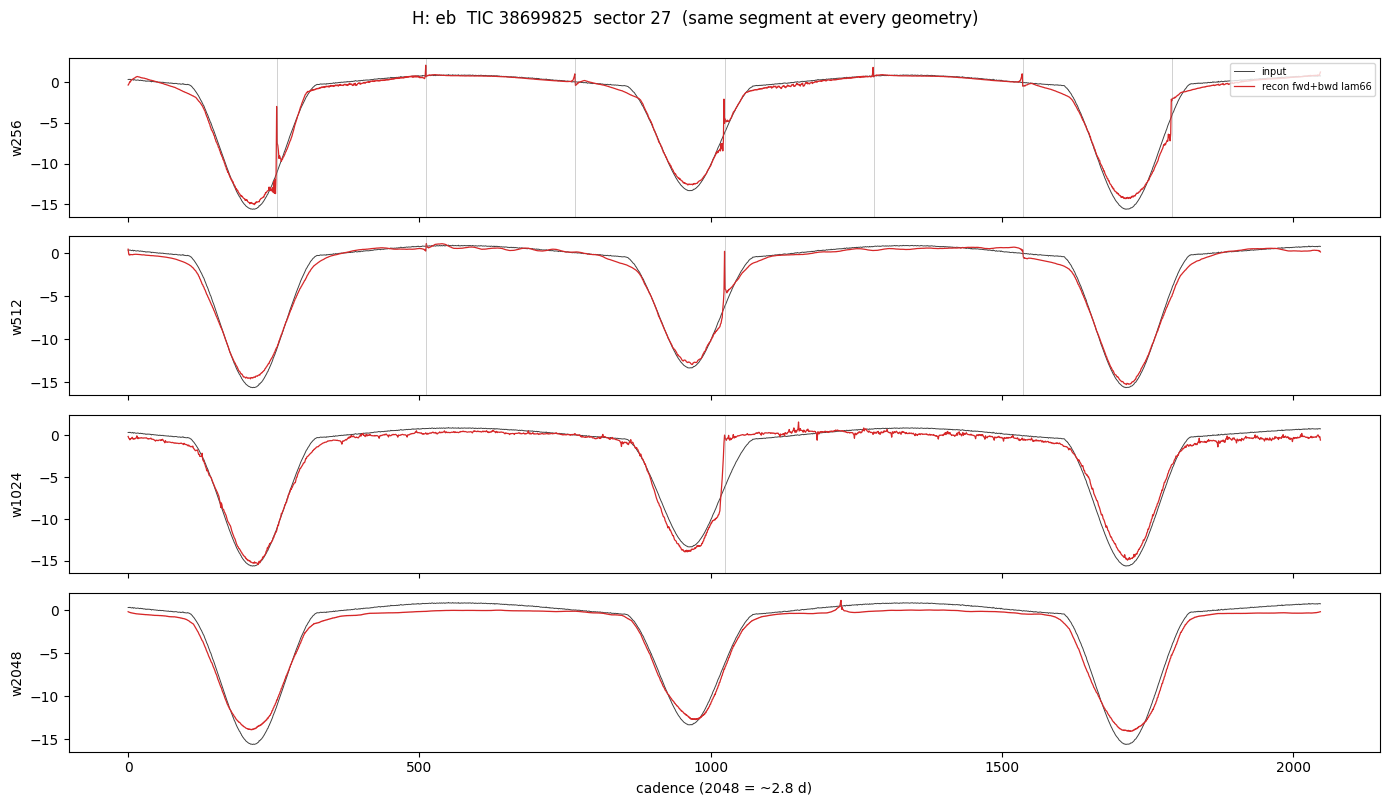

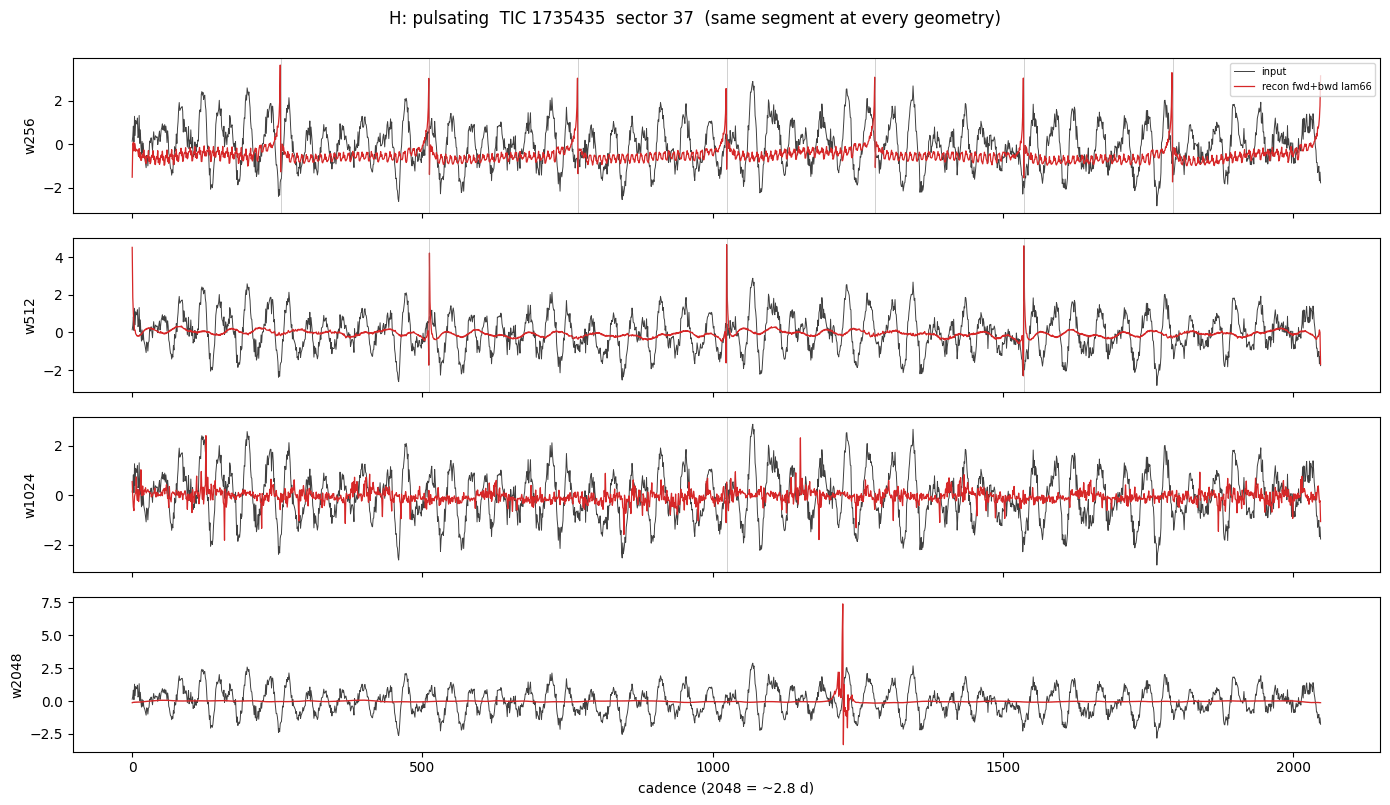

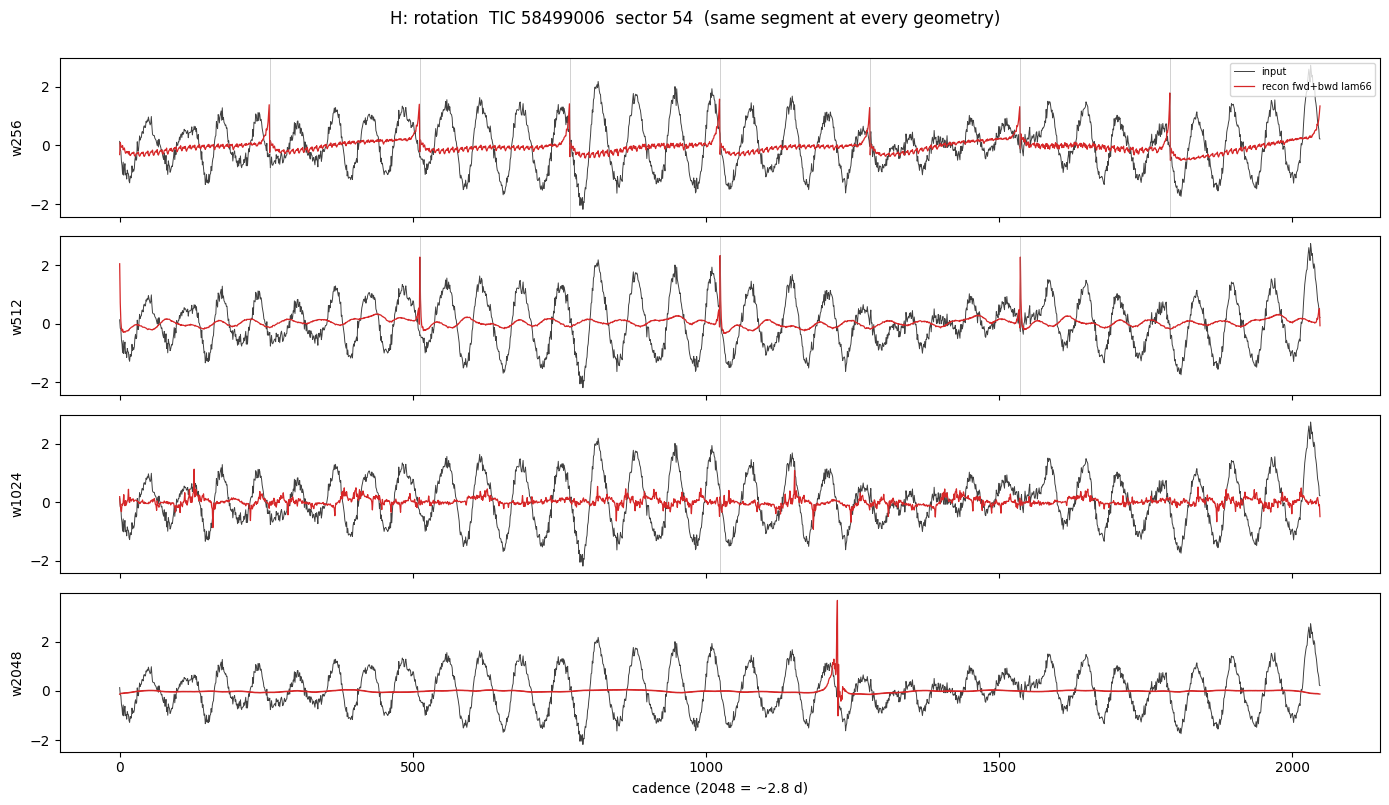

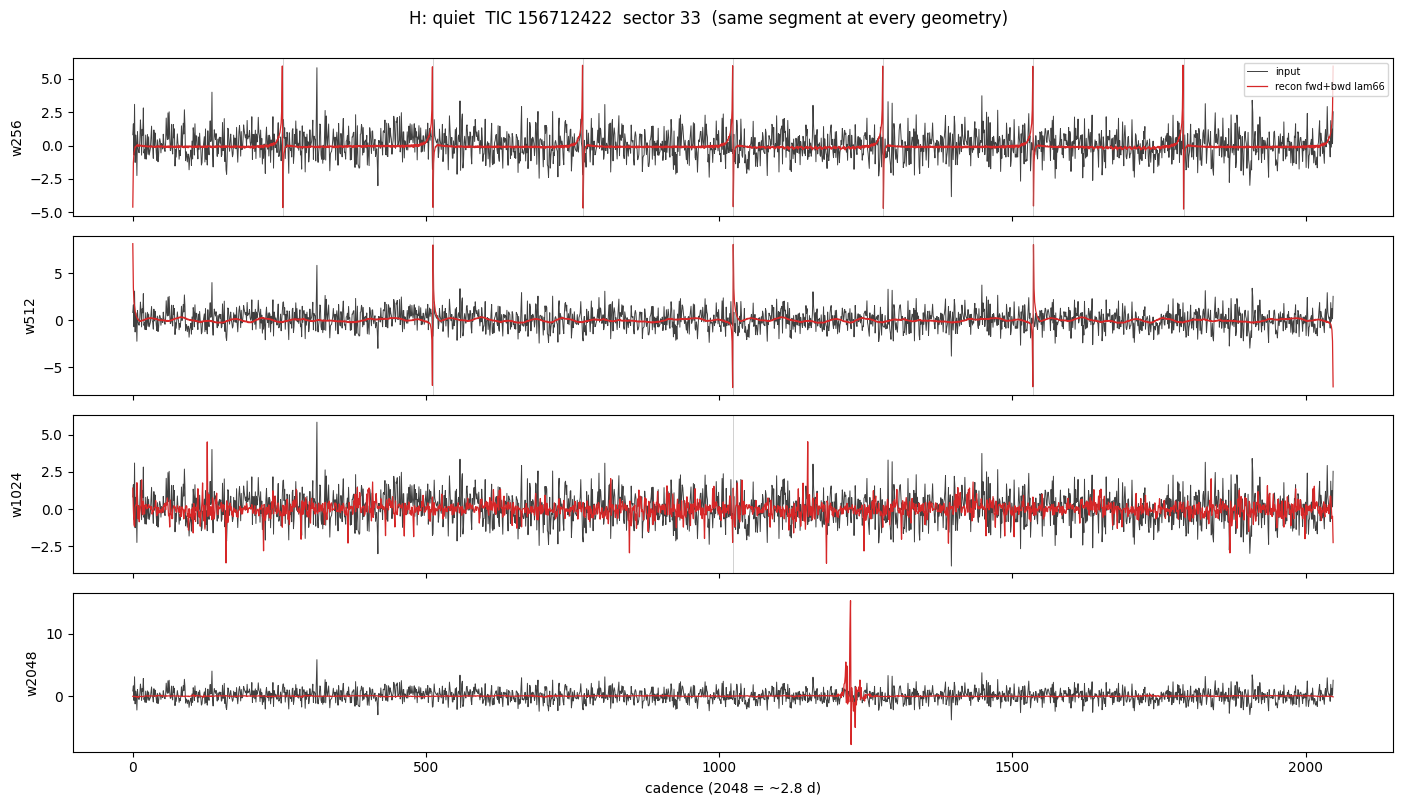

In [23]:
# H1 - one star per class, reconstructed at every geometry over the same 2048 cadences
rng = np.random.default_rng()               # fresh sample every re-run
# rng = np.random.default_rng(0)            # uncomment for a reproducible sample
seg_lookup = common.set_index("tic_id")

for task in ["transit", "eb", "pulsating", "rotation", "quiet"]:
    if not pools[task]:
        continue
    tic = int(rng.choice(pools[task]))
    sector, seg_idx = seg_lookup.loc[tic, ["sector", "seg_idx"]]
    fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
    for ax, w in zip(axes, [256, 512, 1024, 2048]):
        idx, mm = packs[w]
        r = idx[(idx["tic_id"] == tic) & (idx["sector"] == sector) & (idx["seg_idx"] == seg_idx)].iloc[0]
        k = 2048 // w
        blk = np.array(mm[int(r["row_start"]):int(r["row_start"]) + k], dtype=np.float32)
        x = torch.from_numpy(blk).unsqueeze(-1).to(device)
        with torch.no_grad():
            mu, _ = models[w].encoder(x)
            rec = models[w].decoder(mu)
        inp = blk.reshape(-1)
        out = rec[:, :, 0].cpu().numpy().reshape(-1)
        ax.plot(inp, color="k", lw=0.7, alpha=0.75, label="input")
        ax.plot(out, color="tab:red", lw=0.9, label=f"recon {PANEL[w][1]}")
        for b in range(w, 2048, w):
            ax.axvline(b, color="grey", lw=0.5, alpha=0.5)
        ax.set_ylabel(f"w{w}")
        if ax is axes[0]:
            ax.legend(fontsize=7, loc="upper right")
    axes[-1].set_xlabel("cadence (2048 = ~2.8 d)")
    fig.suptitle(f"H: {task}  TIC {tic}  sector {sector}  (same segment at every geometry)", y=1.0)
    plt.tight_layout(); fig.savefig(figs_dir / f"H_lightcurve_{task}.png", dpi=120, bbox_inches="tight")
    plt.show()

#### Plain-English read of H

Each figure is one star's identical 2048 cadences seen by the four geometries; grey verticals are window boundaries, i.e. the points where the encoder's context is cut. Longer windows visibly contain whole eclipse/rotation cycles that 256 slices apart, which is exactly the per-window quality gain kmatch4 measured in C5, and yet section C shows the star level never cashes it in because the short-window bags hold proportionally more windows. Reconstruction quality at the boundaries also shows section F's edge behaviour without any instrumentation.

## I. W&B curve forensics (exp05 + exp06) : what the training curves say about exp07

Cross-experiment inspection of the dumped W&B histories (`exp05_forensics/curves_exp05`, 48 runs at 256x16/ep60/4 seeds; `exp06_forensics/curves_exp06`, geometry sweep at ep100/6 seeds), joined to the per-seed probe scores (exp05 `results/readout_sweep.csv` logistic x mean; exp06 `exp06_geometry_gap.csv` mean_resid, trained arm). It extends A2 (truncation), A4 (dose at selection), and B3 (recruitment transient) from checkpoints to full trajectories, and asks whether the validation loss could have picked the probe winners. Three ground rules: val-loss rankings only within a comparability family (same recon/aux function on the same data; `val/monitor_recon_aux` = recon + w*aux is lambda-free in both experiments because `select_include_dyn=false`); "probe winner" uses the standard per-experiment probe tables, since window-score/MIL numbers exist only for `exp05_comb_fbwd_c1p0` and `exp05_comb_off` (low-risk substitution: MIL pooling was measured rank-equivalent to simple pooling, and both rankings crown the same exp05 cell); the fb0.02 edge cell is excluded throughout.

In [24]:
# I0 - setup: exp05 curve dump, per-run curve summaries, per-seed probe scores, comparability families
from scipy.stats import spearmanr

CURVES05 = root / "experiments" / "exp05_forensics" / "curves_exp05"
assert CURVES05.exists(), "run swm.eval.dump_wandb_history --groups exp05 first"
WARMUP = 10  # beta_warmup_epochs in both experiments; selection is restricted to epoch >= WARMUP
LAM = {"exp05_comb_off": 0, "exp05_comb_fwd_c0p1": 13, "exp05_comb_fwd_c0p3": 40, "exp05_comb_fwd_c1p0": 130,
       "exp05_comb_fbwd_c0p1": 7, "exp05_comb_fbwd_c0p3": 20, "exp05_comb_fbwd_c1p0": 66,
       "exp05_comb_multi_c0p1": 5, "exp05_comb_multi_c0p3": 14, "exp05_comb_multi_c1p0": 48,
       "exp05_lpsd_off": 0, "exp05_lpsd_multi_c1p0": 32,
       "exp06_w256_off": 0, "exp06_w512_off": 0, "exp06_w1024_off": 0, "exp06_w2048_off": 0,
       "exp06_w256_fbwd": 66, "exp06_w512_fbwd": 18, "exp06_w1024_fbwd": 18}
FAMILIES = {  # val-loss rankings are only meaningful where the loss is the same function of the same data
    "exp05_comb": [c for c in LAM if c.startswith("exp05_comb")],
    "exp05_lpsd": ["exp05_lpsd_off", "exp05_lpsd_multi_c1p0"],
    "exp06_w256": ["exp06_w256_off", "exp06_w256_fbwd"],
    "exp06_w512": ["exp06_w512_off", "exp06_w512_fbwd"],
    "exp06_w1024": ["exp06_w1024_off", "exp06_w1024_fbwd"]}


def curve(cell, seed):
    """load_curve extended to either experiment's dump directory (same killedprefix stitch rule)."""
    if not cell.startswith("exp05"):
        return load_curve(cell, seed)
    stem = f"{cell}_B_seed{seed}"
    main = pd.read_csv(CURVES05 / f"{stem}.csv")
    prefix_path = CURVES05 / f"{stem}.killedprefix.csv"
    if prefix_path.exists():
        prefix = pd.read_csv(prefix_path)
        prefix = prefix[prefix["epoch"] < main["epoch"].min()]
        main = pd.concat([prefix, main], ignore_index=True).sort_values("epoch").reset_index(drop=True)
    return main


def seeds_of(cell):
    """exp05 ran 4 seeds, exp06 ran 6."""
    return list(range(4)) if cell.startswith("exp05") else SEEDS


RUNS_I = []
for cell_i in LAM:
    for seed_i in seeds_of(cell_i):
        RUNS_I.append((cell_i, seed_i))

rows = []
for cell_i, seed_i in RUNS_I:
    cur = curve(cell_i, seed_i)
    post = cur[cur["epoch"] >= WARMUP]
    rows.append({"cell": cell_i, "seed": seed_i,
                 "min_mra": post["val/monitor_recon_aux"].min(),  # recon + w*aux, lambda-free in BOTH exps
                 "min_recon": post["val/recon"].min(),
                 "argmin_mra": int(post.loc[post["val/monitor_recon_aux"].idxmin(), "epoch"]),
                 "n_active_final": cur["val/n_active_units"].iloc[-1],
                 "n_active_peak": cur[cur["epoch"] >= 5]["val/n_active_units"].max()})
run_sum = pd.DataFrame(rows)

ds_rows = []
for cell_i in FAMILIES["exp05_comb"] + FAMILIES["exp05_lpsd"]:
    sweep = pd.read_csv(root / "experiments" / cell_i / "results" / "readout_sweep.csv")
    sweep = sweep[(sweep["readout"] == "logistic") & (sweep["pooling"] == "mean")]
    for _, r in sweep.iterrows():
        ds_rows.append({"cell": cell_i, "seed": int(r["seed"]), "task": r["task"], "pr_auc": r["pr_auc"]})
g6 = gap[(gap["pooling"] == "mean_resid") & (gap["arm"] == "trained") & (gap["seed"] >= 0)]
for _, r in g6.iterrows():
    ds_rows.append({"cell": r["cell"], "seed": int(r["seed"]), "task": r["task"], "pr_auc": r["pr_auc"]})
ds = pd.DataFrame(ds_rows)
print(len(run_sum), "runs summarised |", len(ds), "per-seed probe rows |",
      "exp05 max epoch", int(curve("exp05_comb_off", 0)["epoch"].max()))

90 runs summarised | 360 per-seed probe rows | exp05 max epoch 59


In [25]:
# I1 - winner autopsy: per family x task, the probe winner vs the val-loss winner
rows = []
for fam, fam_cells in FAMILIES.items():
    val_cell = run_sum[run_sum["cell"].isin(fam_cells)].groupby("cell")[["min_recon", "min_mra"]].mean()
    d = ds[ds["cell"].isin(fam_cells)]
    for task in TASKS:
        sc = d[d["task"] == task].groupby("cell")["pr_auc"].mean()
        both = pd.concat([sc.rename("pr_auc"), val_cell], axis=1).dropna()
        ds_w = both["pr_auc"].idxmax()
        rec_w = both["min_recon"].idxmin()
        mra_w = both["min_mra"].idxmin()
        rows.append({"family": fam, "task": task, "n_cells": len(both),
                     "probe_winner": ds_w.replace(f"{fam.split('_')[0]}_", ""),
                     "recon_winner": rec_w.replace(f"{fam.split('_')[0]}_", ""),
                     "recon_aux_winner": mra_w.replace(f"{fam.split('_')[0]}_", ""),
                     "agree": ds_w == mra_w,
                     "prauc_lost_if_recon": both["pr_auc"].max() - both.loc[rec_w, "pr_auc"],
                     "prauc_lost_if_recon_aux": both["pr_auc"].max() - both.loc[mra_w, "pr_auc"]})
winners = pd.DataFrame(rows)
winners.round(3)

,family,task,n_cells,probe_winner,recon_winner,recon_aux_winner,agree,prauc_lost_if_recon,prauc_lost_if_recon_aux
0,exp05_comb,transit,10,comb_fwd_c1p0,comb_off,comb_fwd_c0p1,False,0.035,0.027
1,exp05_comb,eb,10,comb_fbwd_c0p3,comb_off,comb_fwd_c0p1,False,0.029,0.011
2,exp05_comb,pulsating,10,comb_fwd_c1p0,comb_off,comb_fwd_c0p1,False,0.021,0.014
3,exp05_comb,rotation,10,comb_fbwd_c0p3,comb_off,comb_fwd_c0p1,False,0.049,0.033
4,exp05_lpsd,transit,2,lpsd_multi_c1p0,lpsd_off,lpsd_off,False,0.016,0.016
5,exp05_lpsd,eb,2,lpsd_multi_c1p0,lpsd_off,lpsd_off,False,0.013,0.013
6,exp05_lpsd,pulsating,2,lpsd_multi_c1p0,lpsd_off,lpsd_off,False,0.037,0.037
7,exp05_lpsd,rotation,2,lpsd_off,lpsd_off,lpsd_off,True,0.000,0.000
8,exp06_w256,transit,2,w256_fbwd,w256_off,w256_fbwd,True,0.033,0.000
9,exp06_w256,eb,2,w256_fbwd,w256_off,w256_fbwd,True,0.063,0.000


#### Plain-English read of I1

The motivating question was "are the downstream winners the models with the least validation loss?" and the answer is a clean NO wherever the dynamics dose was actually delivered. In the ten-cell exp05 comb family, best val recon crowns `comb_off` on all four tasks while the probe winner is always a dynamics-weighted cell, at a cost of 0.02-0.05 PR-AUC if one had trusted the loss; the lambda-free recon+aux metric crowns `fwd_c0p1` instead, also never the probe winner. In exp06 the same metric DOES pick the probe winner (fwd+bwd) at w256 and w512 on every task, because at delivered dose the dynamics term also improves recon+aux; at w1024, where A4 showed the dose shortfall, off wins both columns and the disagreement vanishes. So val loss and probe quality diverge exactly where the dynamics term is doing its job: the "least-val-loss" model is systematically the dyn-off (or weakest-lambda) one, and that config difference is the low-pass shortcut expressed in curve space.

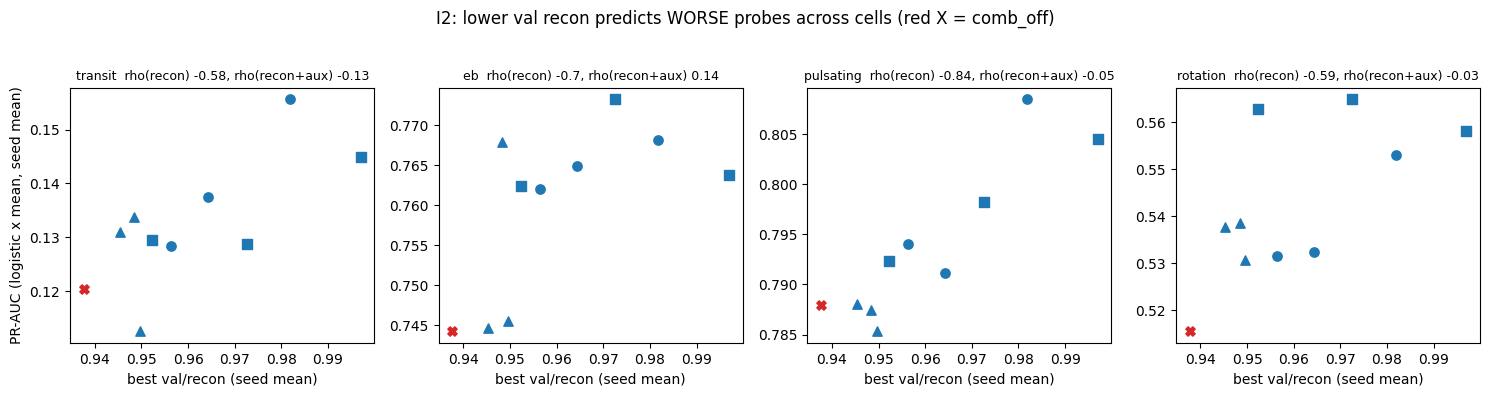

In [26]:
# I2 - cell-level predictiveness inside the ten-cell exp05 comb family: val minima vs probe score
comb = FAMILIES["exp05_comb"]
val_cell = run_sum[run_sum["cell"].isin(comb)].groupby("cell")[["min_recon", "min_mra"]].mean()
markers = {"off": "X", "fwd": "o", "fbwd": "s", "multi": "^"}

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, task in zip(axes, TASKS):
    sc = ds[(ds["cell"].isin(comb)) & (ds["task"] == task)].groupby("cell")["pr_auc"].mean()
    both = pd.concat([sc.rename("pr_auc"), val_cell], axis=1).dropna()
    for cell_name, r in both.iterrows():
        mode = cell_name.split("_")[2]  # off / fwd / fbwd / multi
        ax.scatter(r["min_recon"], r["pr_auc"], marker=markers[mode],
                   color="tab:red" if mode == "off" else "tab:blue", s=45)
    rho_r = spearmanr(-both["min_recon"], both["pr_auc"]).statistic
    rho_m = spearmanr(-both["min_mra"], both["pr_auc"]).statistic
    ax.set_title(f"{task}  rho(recon) {round(rho_r, 2)}, rho(recon+aux) {round(rho_m, 2)}", fontsize=9)
    ax.set_xlabel("best val/recon (seed mean)")
axes[0].set_ylabel("PR-AUC (logistic x mean, seed mean)")
fig.suptitle("I2: lower val recon predicts WORSE probes across cells (red X = comb_off)", y=1.03)
plt.tight_layout(); fig.savefig(figs_dir / "I2_valloss_scatter.png", dpi=120, bbox_inches="tight"); plt.show()

#### Plain-English read of I2

The scatter makes I1 quantitative: across the ten comb cells the rank correlation between best val recon and probe score is strongly NEGATIVE on every task (eb -0.70, pulsating -0.84, rotation -0.59, transit -0.58), i.e. the models the reconstruction loss loves most are the ones the probe likes least, with comb_off sitting at the best-recon/worst-probe corner every time. This is the low-pass-shortcut story measured in curve space: the dynamics term buys probe quality by spending reconstruction. The lambda-free recon+aux metric is merely uncorrelated (rho -0.13 to +0.14), better than anti-predictive but still useless for picking a winner, which is why the probe gates, not the val loss, must remain the cross-model selector.

In [27]:
# I3 - seed-level: within a cell, does any curve metric pick the downstream-best seed?
rows = []
for (cell, task), d in ds.groupby(["cell", "task"]):
    m = d.merge(run_sum[["cell", "seed", "min_mra", "min_recon", "n_active_final", "n_active_peak"]],
                on=["cell", "seed"])
    if len(m) < 4 or m["pr_auc"].nunique() < 2:
        continue
    rows.append({"cell": cell, "task": task, "n_seeds": len(m),
                 "rho_recon_aux": spearmanr(-m["min_mra"], m["pr_auc"]).statistic,
                 "rho_recon": spearmanr(-m["min_recon"], m["pr_auc"]).statistic,
                 "rho_nact_final": spearmanr(m["n_active_final"], m["pr_auc"]).statistic,
                 "rho_nact_peak": spearmanr(m["n_active_peak"], m["pr_auc"]).statistic})
seed_pred = pd.DataFrame(rows)
by_task = seed_pred.groupby("task")[["rho_recon_aux", "rho_recon", "rho_nact_final", "rho_nact_peak"]]
by_task.agg(["mean", "std"]).round(2)

rho_recon_aux       rho_recon       rho_nact_final        \
                   mean   std      mean   std           mean   std   
task                                                                 
eb                -0.10  0.44     -0.27  0.43          -0.18  0.43   
pulsating          0.17  0.67     -0.01  0.68          -0.16  0.58   
rotation           0.01  0.49     -0.07  0.56          -0.02  0.44   
transit            0.02  0.49     -0.03  0.59           0.25  0.45   

          rho_nact_peak        
                   mean   std  
task                           
eb                -0.19  0.51  
pulsating          0.02  0.54  
rotation          -0.01  0.53  
transit           -0.23  0.62

#### Plain-English read of I3

Within a cell, no logged quantity ranks seeds: every mean rank correlation sits inside +/-0.3 of zero on 4-6 seeds, for the selection metric, pure recon, and both n_active summaries alike. The seed that trains to the lowest validation loss is not the seed whose mu probes best, so exp07 must not seed-select on any curve-derived number; the honest unit stays the seed-averaged cell with its SE. The n_active columns extend E4b/B3 one step: not only is n_active the wrong checkpoint-selection signal, its peak height during the recruitment transient does not predict downstream quality across seeds either.

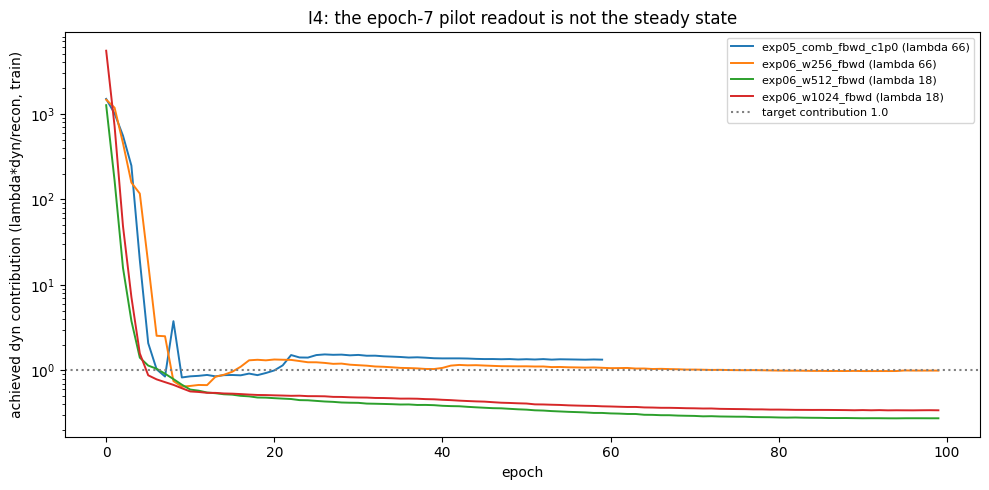

,cell,lambda,dose_ep7,dose_steady,lambda_for_target_1.0
0,exp05_comb_fbwd_c1p0,66,0.847,1.342,49.193
1,exp06_w256_fbwd,66,2.506,0.988,66.799
2,exp06_w512_fbwd,18,0.914,0.275,65.357
3,exp06_w1024_fbwd,18,0.728,0.342,52.676


In [28]:
# I4 - dyn-dose trajectories for every fwd+bwd cell, and the steady-state lambda back-out
fbwd_dose = ["exp05_comb_fbwd_c1p0", "exp06_w256_fbwd", "exp06_w512_fbwd", "exp06_w1024_fbwd"]
rows = []
plt.figure(figsize=(10, 5))
for j, cell in enumerate(fbwd_dose):
    per_seed = []
    for seed in seeds_of(cell):
        cur = curve(cell, seed).set_index("epoch")
        per_seed.append(LAM[cell] * cur["train/dyn"] / cur["train/recon"])
    dose = pd.concat(per_seed, axis=1).mean(axis=1)
    plt.plot(dose.index, dose.values, lw=1.4, color=plt.cm.tab10(j), label=f"{cell} (lambda {LAM[cell]})")
    steady = dose[dose.index >= dose.index.max() - 9].mean()
    rows.append({"cell": cell, "lambda": LAM[cell], "dose_ep7": dose.loc[7], "dose_steady": steady,
                 "lambda_for_target_1.0": LAM[cell] / steady})
plt.axhline(1.0, color="grey", ls=":", label="target contribution 1.0")
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("achieved dyn contribution (lambda*dyn/recon, train)")
plt.legend(fontsize=8); plt.title("I4: the epoch-7 pilot readout is not the steady state")
plt.tight_layout(); plt.savefig(figs_dir / "I4_dyn_dose.png", dpi=120, bbox_inches="tight"); plt.show()
pd.DataFrame(rows).round(3)

#### Plain-English read of I4

Both epoch-7-calibrated lambdas (w512/w1024 at 18) sink to ~0.3x target and are still drifting down at epoch 100, while the two steady-state-calibrated cells (lambda 66 at 256x16) hold ~1.0-1.3x: A4's dose shortfall is a calibration-timing artifact, not a property of the larger windows. The back-out column is the striking part: the lambda that WOULD have delivered target contribution at steady state is ~49-67 at every geometry, a narrow band despite recon and dyn each changing scale with window. It is a lower-bound guide (raising lambda also suppresses dyn, the same undershoot the exp05 runner documented), so exp07's rule is: pilot at steady state (>= 40 epochs), start fwd+bwd near lambda 60, and gate on the achieved dose at eval.

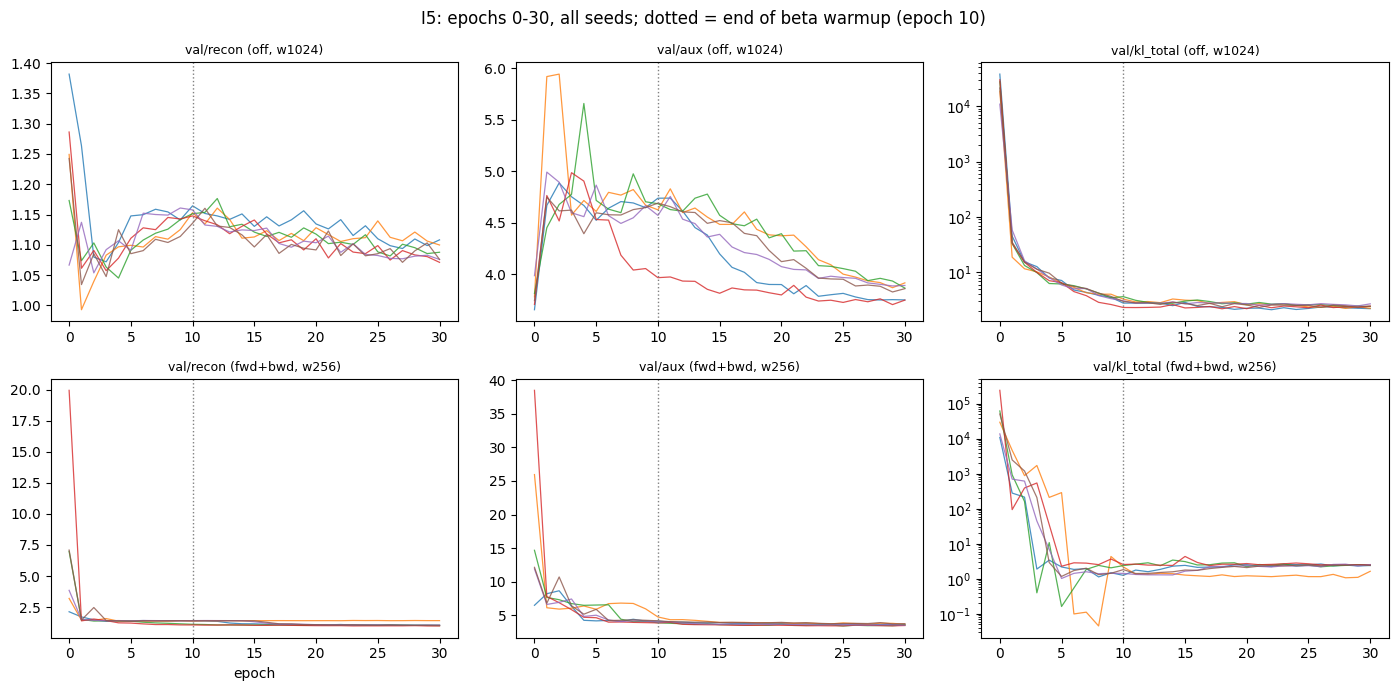

exp                            exp05  exp06
recon_ep1_over_ep0     median  0.675  0.915
                       mean    0.640  0.851
aux_ep1_over_ep0       median  0.889  1.222
                       mean    0.982  1.244
dyn_ep1_over_ep0       median  0.006  0.009
                       mean    0.107  0.042
kl_total_ep1_over_ep0  median  0.006  0.004
                       mean    0.025  0.013
aux_ep2_over_ep0       median  0.849  1.199
                       mean    0.877  1.206
aux_rose_ep1_3         median  0.000  1.000
                       mean    0.479  0.881
kl_kink_ep10_x_typical median  2.085  2.447
                       mean    2.803  3.055

In [29]:
# I5 - warmup-transient anatomy: what actually moves in epochs 0-30, and the two ep0->1 questions
show = [("exp06_w1024_off", "off, w1024"), ("exp06_w256_fbwd", "fwd+bwd, w256")]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for row, (cell, label) in enumerate(show):
    for col, metric in enumerate(["val/recon", "val/aux", "val/kl_total"]):
        ax = axes[row, col]
        for seed in seeds_of(cell):
            early = curve(cell, seed)
            early = early[early["epoch"] <= 30]
            ax.plot(early["epoch"], early[metric], lw=0.9, alpha=0.8)
        ax.axvline(WARMUP, color="grey", ls=":", lw=1)  # beta reaches beta_target here
        if metric == "val/kl_total":
            ax.set_yscale("log")
        ax.set_title(f"{metric} ({label})", fontsize=9)
axes[1, 0].set_xlabel("epoch")
fig.suptitle("I5: epochs 0-30, all seeds; dotted = end of beta warmup (epoch 10)")
plt.tight_layout(); fig.savefig(figs_dir / "I5_warmup_anatomy.png", dpi=120, bbox_inches="tight"); plt.show()

# ep0->1 / ep0->2 ratios per component, the free-bits floor check, and the warmup-boundary kink size
rows = []
for cell, seed in RUNS_I:
    cur = curve(cell, seed).set_index("epoch")
    floor_gap = (cur["val/kl_loss"] - cur["val/kl_total"]).abs().max()
    if cell.startswith("exp05_lpsd"):
        assert floor_gap > 0  # lpsd recipe runs free_bits=0.02: the floor engages, at ALL epochs
    else:
        assert floor_gap == 0  # comb recipe + exp06: free_bits=0.0, kl_loss is identically kl_total
    row = {"exp": cell.split("_")[0]}
    for metric in ["val/recon", "val/aux", "val/dyn", "val/kl_total"]:
        row[f"{metric.split('/')[1]}_ep1_over_ep0"] = cur.loc[1, metric] / cur.loc[0, metric]
    row["aux_ep2_over_ep0"] = cur.loc[2, "val/aux"] / cur.loc[0, "val/aux"]
    row["aux_rose_ep1_3"] = cur.loc[1:3, "val/aux"].max() > cur.loc[0, "val/aux"]
    typical = cur.loc[11:20, "val/kl_total"].diff().abs().mean()
    row["kl_kink_ep10_x_typical"] = abs(cur.loc[10, "val/kl_total"] - cur.loc[9, "val/kl_total"]) / typical
    rows.append(row)
anatomy = pd.DataFrame(rows)
anatomy.groupby("exp").agg(["median", "mean"]).T.round(3)

#### Plain-English read of I5

Two W&B-viewer puzzles resolved. **(a) The "weird increase" after epoch 0 is the aux term, and it is expected.** The epoch-0 row is already one full epoch of beta=0 training, so recon, dyn, KL, and mu_var all crash 10-200x into epoch 1; val/aux instead RISES in exp06 (median x1.2 by epoch 1, and 88% of runs sit above their epoch-0 value somewhere in epochs 1-3, in dyn-off cells too, so the dynamics term is not the cause): early optimization spends the decoder on time-MSE at the expense of spectral fidelity, and aux only wins its term back once recon flattens (~epoch 5). In exp05 the same competition is milder, aux merely stalls (x0.85-0.9 while recon drops x0.68, with about half the runs showing a transient rise). The second increase, visible at the large-window off cells, is val/recon itself creeping up from epoch ~2 to ~10: that is the beta warmup squeezing KL and buying prior compliance with reconstruction, i.e. the rate-distortion trade, not a bug. **(b) There are no "free bits for the first 10 epochs" anywhere.** free_bits is a constant per-dim floor with no schedule: it is 0.0 in every comb-recipe and exp06 run (the kl_loss == kl_total identity asserted above proves the floor never engaged), and 0.02 in the two lpsd hedge cells, where the floor engages at ALL epochs, not the first 10. The 10-epoch knob is the linear beta warmup, and the logged KL is the raw unweighted value, so nothing is expected to jump when beta stops rising at epoch 10: the ramp is continuous, only its slope ends. The measured epoch 9-->10 step is ~2x a typical adjacent-epoch step, a kink, not a discontinuity.

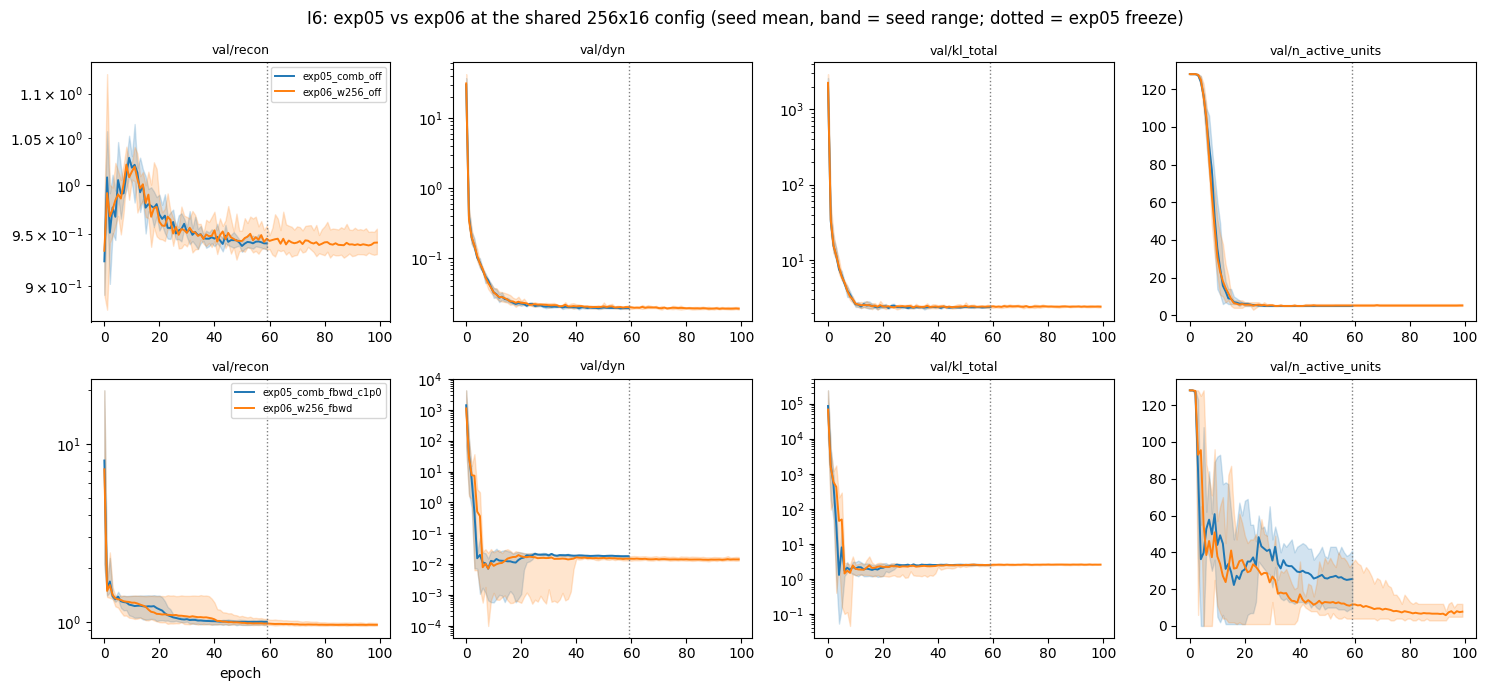

In [30]:
# I6 - replication: the two w256 cells exp06 nominally re-ran from exp05, curves overlaid
pairs = [("exp05_comb_off", "exp06_w256_off"), ("exp05_comb_fbwd_c1p0", "exp06_w256_fbwd")]
rep_metrics = ["val/recon", "val/dyn", "val/kl_total", "val/n_active_units"]

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for row, (c5, c6) in enumerate(pairs):
    for col, metric in enumerate(rep_metrics):
        ax = axes[row, col]
        for cell, color in [(c5, "tab:blue"), (c6, "tab:orange")]:
            per_seed = []
            for seed in seeds_of(cell):
                per_seed.append(curve(cell, seed).set_index("epoch")[metric])
            allc = pd.concat(per_seed, axis=1)
            ax.plot(allc.index, allc.mean(axis=1), color=color, lw=1.4, label=cell)
            ax.fill_between(allc.index, allc.min(axis=1), allc.max(axis=1), color=color, alpha=0.2)
        ax.axvline(59, color="grey", ls=":", lw=1)  # exp05 freeze epoch
        if metric != "val/n_active_units":
            ax.set_yscale("log")
        ax.set_title(metric, fontsize=9)
        if col == 0:
            ax.legend(fontsize=7)
axes[1, 0].set_xlabel("epoch")
fig.suptitle("I6: exp05 vs exp06 at the shared 256x16 config (seed mean, band = seed range; dotted = exp05 freeze)")
plt.tight_layout(); fig.savefig(figs_dir / "I6_replication.png", dpi=120, bbox_inches="tight"); plt.show()

#### Plain-English read of I6

The protocol changes between the experiments (ep60 --> ep100, 4 --> 6 seeds) did not move the training dynamics: recon, dyn, and KL overlap through the shared epoch range for both the off pair and the fwd+bwd pair, so exp05 and exp06 numbers disagree only where their eval protocols differ, not because training drifted. The one visible divergence is n_active after ~ep40, which is exactly the B3 recruitment transient mid-decay: exp05's freeze at 60 caught ~25 units on the way down, and the ep100 runs complete the decay to <10. This retroactively re-dates exp05's "collapse-reversal" as a snapshot of a transient, not a steady state.

#### I7. What the curves say about exp07

Mapped onto the three planned exp07 axes, plus two protocol rules the curve forensics adds:

1. **Lambda calibration (axis: dose).** Calibrate at steady state, never at epoch 7: the achieved contribution keeps falling for 20+ epochs after the pilot readout (I4). The steady-state back-out lands in a narrow band (lambda ~49-67 for fwd+bwd at every geometry tested), so exp07 should start fwd+bwd pilots near lambda ~60, run them >= 40 epochs, and re-verify the achieved dose at eval as a pre-registered gate. The back-out is a lower-bound guide, not an exact dial: raising lambda suppresses dyn itself, so expect one calibrate-verify iteration.
2. **Phase-aware / STFT aux (axis: objective).** The early-epoch anatomy (I5) shows the aux term is the one that loses the opening trade against time-MSE; a new spectral aux will show the same ep0-3 spike, which is a benign transient, not a divergence. Do not tune on the first epochs. The aux term is also the knob that co-moves with downstream quality (I1: recon+aux picks the downstream-winning arm at full dose, pure recon anti-picks it), consistent with F1 crediting recon_aux for edge immunity: the objective axis is where exp07 leverage lives.
3. **Edge fix (axis: defect).** No curve-level counter-evidence: nothing in the loss trajectories distinguishes edge-spiking runs, so the fix stays a decoder/aux-side change (F1), not a training-schedule change.
4. **Protocol rule: never select models by validation loss.** Across cells, min val recon picks the dyn-off cell for every task while the downstream winner is always a dynamics cell (I1), with strongly negative rank correlation (I2); across seeds within a cell, no logged metric ranks seeds usefully (I3). Cross-model selection in exp07 must go through the probe gates; per-run checkpoint selection can stay on the lambda-free recon+aux metric (C1 replicated under it), but its argmin still rides the truncation edge (A2), so budget epochs or a convergence stop.
5. **Protocol rule: report seed spread, do not seed-select.** Val-loss seed-picking is noise (I3); the honest unit is the seed-averaged cell with SE, as the gates already do.

## Summary

- **H1 (window length is the binding constraint): NOT SUPPORTED.** All four pre-registered gate-arm differentials fail (C1/C2); the dyn-off nominal passes decompose into the pulsating control falling (C3); w2048 drops every task despite eb coverage exceeding 50% (C4). Mechanism: per-window quality rises with window but bag size compensates exactly at a fixed cadence budget (C5).
- **H2 (re-open rollout eval): NO at every geometry.** Lag-1 mu-ACF on periodic stars runs -0.006 --> -0.232 as the window grows, never approaching 0.3, and the untrained reference tracks the trained arms (D1/D2): the anti-correlation is a windowing property, and the dynamics axis is ill-posed across the whole v1 window family.
- **C1 (dynamics weighting helps the frozen representation): REPLICATES at 256x16** under ep100/6 seeds (eb, rotation, transit > 2*SE; pulsating ns) and weakens with window (E1), with the caveat from A4 that the achieved dyn contribution ran at only ~0.3x target at w512/w1024, so dose and geometry are conflated at the larger windows.
- **New mechanism observation (B3): recruitment is a transient.** fwd+bwd re-recruits to ~40 units around epochs 15-35, re-collapses under 10 by epoch 50, and the selected checkpoints sit long after; C1 still replicates there, so the benefit does not require elevated n_active at selection (reinforces exp05 E4b: do not select on n_active).
- **Run hygiene (A2): truncation persists at ep100.** 5-6 of 6 seeds in every cell still select within their last 10 epochs; paired results are unaffected, absolute levels remain ceilings-in-progress.
- **Edge: recon_aux is CONFIRMED as the immunity knob** (spike survives free_bits 0.02 at 15.3x, F1); fix + ADR queued for exp07.
- **SSL learning is real at every geometry** (eb gap +0.12 to +0.13 vs capacity-matched untrained) except transit, which goes negative at 512/1024 (G1).
- **Curve forensics (I): validation loss must never pick models.** Across the exp05 comb family the best-recon cell is dyn-off on every task while the probe winner is always a dynamics cell (rank correlation -0.58 to -0.84, I1/I2); within a cell no logged metric ranks seeds (I3). The lambda-free recon+aux metric agrees with the probe winner only at delivered dose (exp06 w256/w512), so cross-model selection stays with the probe gates.
- **Curve forensics (I4): the dose shortfall is a calibration-timing artifact.** Epoch-7 pilots undershoot because dyn/recon keeps falling for 20+ epochs; the steady-state back-out lands at lambda ~49-67 at EVERY geometry, giving exp07 a concrete starting dial (lambda ~60, steady-state pilot, dose gate at eval).
- **Curve forensics (I5/I6): early-epoch "weirdness" is benign and replication is clean.** The ep0-->1 rise is the aux term losing the opening trade to time-MSE (dyn-off cells show it too); free_bits is an unscheduled constant floor (0.0 in comb/exp06, 0.02 in the lpsd hedge where it engages at all epochs), the 10-epoch knob is the continuous beta warmup, and no KL step at epoch 10 is expected or observed; exp05 vs exp06 at 256x16 overlap through the shared epochs, and exp05's n_active 25 +/- 15 was a mid-decay snapshot of the B3 transient.
- **Consequence: 256x16 stays the geometry of record; the window lever is retired for v1 star-level scores.** The live exp07 levers are the objective (phase-aware/STFT aux), the edge fix, and ML4PS consolidation, with the I7 protocol rules (steady-state lambda calibration, probe-gated selection, no seed selection) layered on top.